# Classifying White Wine Quality Using Machine Learning

## Business Objective

The objective is to develop a classification model that predicts whether a white wine belongs to the lower-quality class or the acceptable/higher-quality class based on its physicochemical properties.

An acceptable/higher-quality wine is defined as one receiving a quality score of 6 or higher. Such a model could provide an initial data-driven quality assessment to support quality-control and product-screening processes in the wine and beverage industry.

## Research Questions

### Primary Research Question

Can a machine-learning classification model predict whether a white wine belongs to the lower-quality class or the acceptable/higher-quality class based on its physicochemical properties?

### Secondary Research Questions

1. Which physicochemical properties contribute most strongly to wine-quality classification?

2. How do K-Nearest Neighbours, Random Forest and Gradient Boosting compare?

3. How do normalization, cross-validation and hyperparameter tuning affect performance?

4. How well does the final model perform overall and for lower-quality wines?

5. How much uncertainty surrounds the final performance estimates, and how can a surrogate model help explain the final classifier?

## Methodology Overview

The project follows a leakage-safe supervised-learning workflow: data quality checks, target engineering, stratified train-test splitting, exploratory analysis, baseline construction, model development, five-fold cross-validation, Grid Search, class-specific evaluation, decision-threshold analysis, bootstrap confidence intervals and surrogate-model interpretation.

All learned preprocessing and model fitting use the training data. The test set is reserved for final evaluation and model comparison.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

wine_df = pd.read_csv("winequality-white.csv", sep=";")

wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


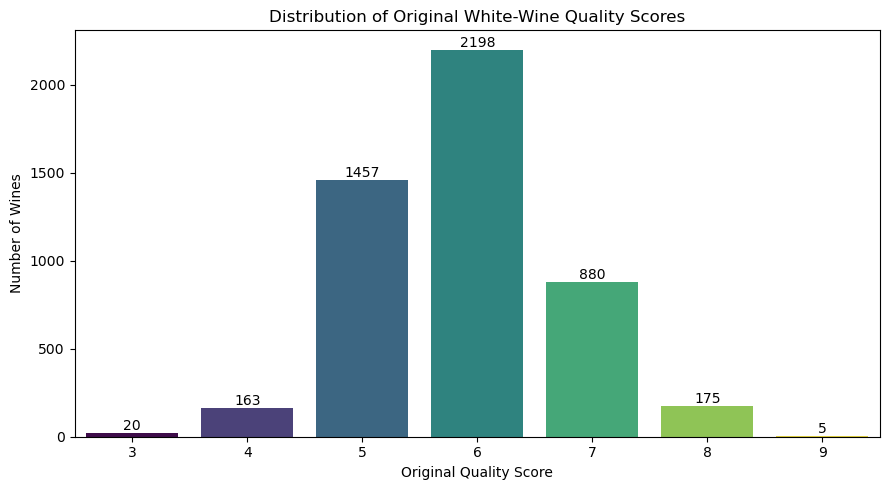

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=wine_df,
    x="quality",
    hue="quality",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Original White-Wine Quality Scores")
plt.xlabel("Original Quality Score")
plt.ylabel("Number of Wines")

# Display the count above every bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [3]:
print("Number of rows:", wine_df.shape[0])
print("Number of columns:", wine_df.shape[1])

wine_df.info()

Number of rows: 4898
Number of columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


## 2. Data Quality Checks

The dataset contains 4,898 white-wine observations and 12 columns.

All columns contain 4,898 non-null values, confirming that there are no missing values in the dataset. Therefore, no missing-value treatment, such as removing rows or filling values, is required.

The dataset will also be checked for duplicated rows before proceeding with the analysis and machine-learning model.

In [4]:
print("Number of duplicated rows:", wine_df.duplicated().sum())

Number of duplicated rows: 937


### Duplicate Treatment

The dataset contained 937 duplicated rows. These rows were removed to prevent identical observations from receiving excessive influence during model training and potentially appearing in both the training and test sets.

After removing duplicates, the cleaned dataset contains 3,961 unique observations.

In [5]:
wine_df = wine_df.drop_duplicates().reset_index(drop=True)

print("Number of rows after removing duplicates:", wine_df.shape[0])
print("Remaining duplicated rows:", wine_df.duplicated().sum())


Number of rows after removing duplicates: 3961
Remaining duplicated rows: 0


## 3. Target Distribution Analysis

The original target variable, `quality`, is an integer score representing the sensory quality assigned to each wine.

Because this project uses **classification**, the numerical quality scores will later be converted into categorical classes. However, the classification threshold should not be selected arbitrarily. We must first examine:

1. The number of observations in each quality category.
2. The percentage represented by each category.
3. Whether the proposed classes would be balanced.
4. Whether a majority-class prediction could already produce high accuracy.

For a quality score \(q\), a possible binary target can be expressed as: y = 0, if q < t
y = 1, if q ≥ t


where:

- \(q\) is the original wine-quality score,
- \(t\) is the classification threshold,
- \(y=0\) represents lower-quality wine,
- \(y=1\) represents higher-quality wine.

The threshold \(t\) will be selected after examining the target distribution.

In [6]:
# Count the number of wines for each quality score
quality_counts = wine_df["quality"].value_counts().sort_index()

# Calculate the percentage distribution
quality_percentages = (
    wine_df["quality"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Combine counts and percentages into one table
quality_distribution = pd.DataFrame({
    "count": quality_counts,
    "percentage": quality_percentages
})

quality_distribution

,count,percentage
quality,,
3,20,0.50
4,153,3.86
5,1175,29.66
6,1788,45.14
7,689,17.39
8,131,3.31
9,5,0.13


## 4. Target Engineering for Binary Classification

The original target, 'quality', contains integer scores from 3 to 9. For this classification task, it is converted into a binary target called  'quality-class'.

The classification rule is: yi​={0,1,​if qi​≤5if qi​≥6​)



where:

- \(q_i\) is the original quality score for wine \(i\),
- \(y_i\) is the newly engineered binary target,
- `0` represents lower-quality wine,
- `1` represents acceptable or higher-quality wine.

The original 'quality' column is retained for interpretation, while 'quality_class' becomes the target used for classification.

This is **target engineering**, not one-hot encoding. One-hot encoding is unnecessary for the predictor variables because all original wine features are numerical.

In [7]:
import numpy as np

# Create the binary classification target
wine_df["quality_class"] = np.where(
    wine_df["quality"] >= 6,
    1,
    0
)

wine_df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1
5,6,1
6,5,0
7,5,0
8,5,0
9,7,1


In [8]:
target_check = (
    wine_df
    .groupby(["quality", "quality_class"])
    .size()
    .reset_index(name="count")
)

target_check

,quality,quality_class,count
0,3,0,20
1,4,0,153
2,5,0,1175
3,6,1,1788
4,7,1,689
5,8,1,131
6,9,1,5


### Rare Target Values and Potential Outliers

The original quality distribution contains several rare scores. In particular, only 20 wines received a quality score of 3, while only 5 wines received a score of 9.

However, a **rare target value** is not automatically an outlier. Rarity describes how frequently a value occurs, whereas an outlier is an observation that lies unusually far from the general distribution.

Before target engineering, "quality" is an ordinal numerical target. After converting the project into a binary classification problem, the original quality scores are grouped as follows:

{3, 4, 5} → 0

{6, 7, 8, 9} → 1

The classes are interpreted as:

- "quality_class" = 0`: below acceptable quality
- "quality_class" = 1`: acceptable-to-higher quality

The number of observations in class 0 is:

20 + 153 + 1175 = 1348

The number of observations in class 1 is:

1788 + 689 + 131 + 5 = 2613

Therefore, the final binary target distribution is approximately:

P(y = 0) = (1348 / 3961) × 100 ≈ 34.03%

P(y = 1) = (2613 / 3961) × 100 ≈ 65.97%

The classification model is not required to predict quality score 9 as an individual class using only five observations. Instead, those wines become part of "quality_class" = 1`, which contains 2,613 observations.

Although the binary classes are not perfectly balanced, both classes contain enough observations for model training. A stratified train-test split will be used to preserve these class proportions in both the training and test datasets.

The rare original quality scores will not be removed simply because they occur infrequently. They may represent genuine wines, and removing valid observations could artificially increase model performance and reduce the model’s ability to generalize to unusual wines.

### Potential Outliers in the Predictor Variables

Potential outliers in the physicochemical predictor variables will be investigated separately using boxplots and the interquartile range.

The interquartile range is calculated as:

IQR = Q3 − Q1
Potential outliers are observations outside the following boundaries:

Lower bound = Q1 − 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

Outliers may affect some machine-learning methods more strongly than others. K-Nearest Neighbors calculates the distance between observations. Using Euclidean distance:
The formula for **Euclidean distance** between two points is:


$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

d(p, q) = distance between two wines
p and q = the two wines being compared
i = each feature/column
n = total number of features
pᵢ and qᵢ = values of feature i for wines p and q



An extreme value in one feature can dominate the distance calculation, causing KNN to identify misleading nearest neighbors.

Outliers can also affect feature scaling:

- "StandardScaler" uses the mean and standard deviation, which are sensitive to extreme values.
- "MinMaxScaler" uses the minimum and maximum, so an extreme value can compress most observations into a narrow range.

However, an observation identified by the IQR rule is only a **potential statistical outlier**. It should not be removed automatically. Each potential outlier must first be investigated to determine whether it is:

- a data-entry error,
- a measurement error,
- physically impossible,
- or a valid but unusual wine.

The approach used in this project is therefore:

> Detect potential outliers, investigate their validity and remove them only when there is sufficient analytical justification.

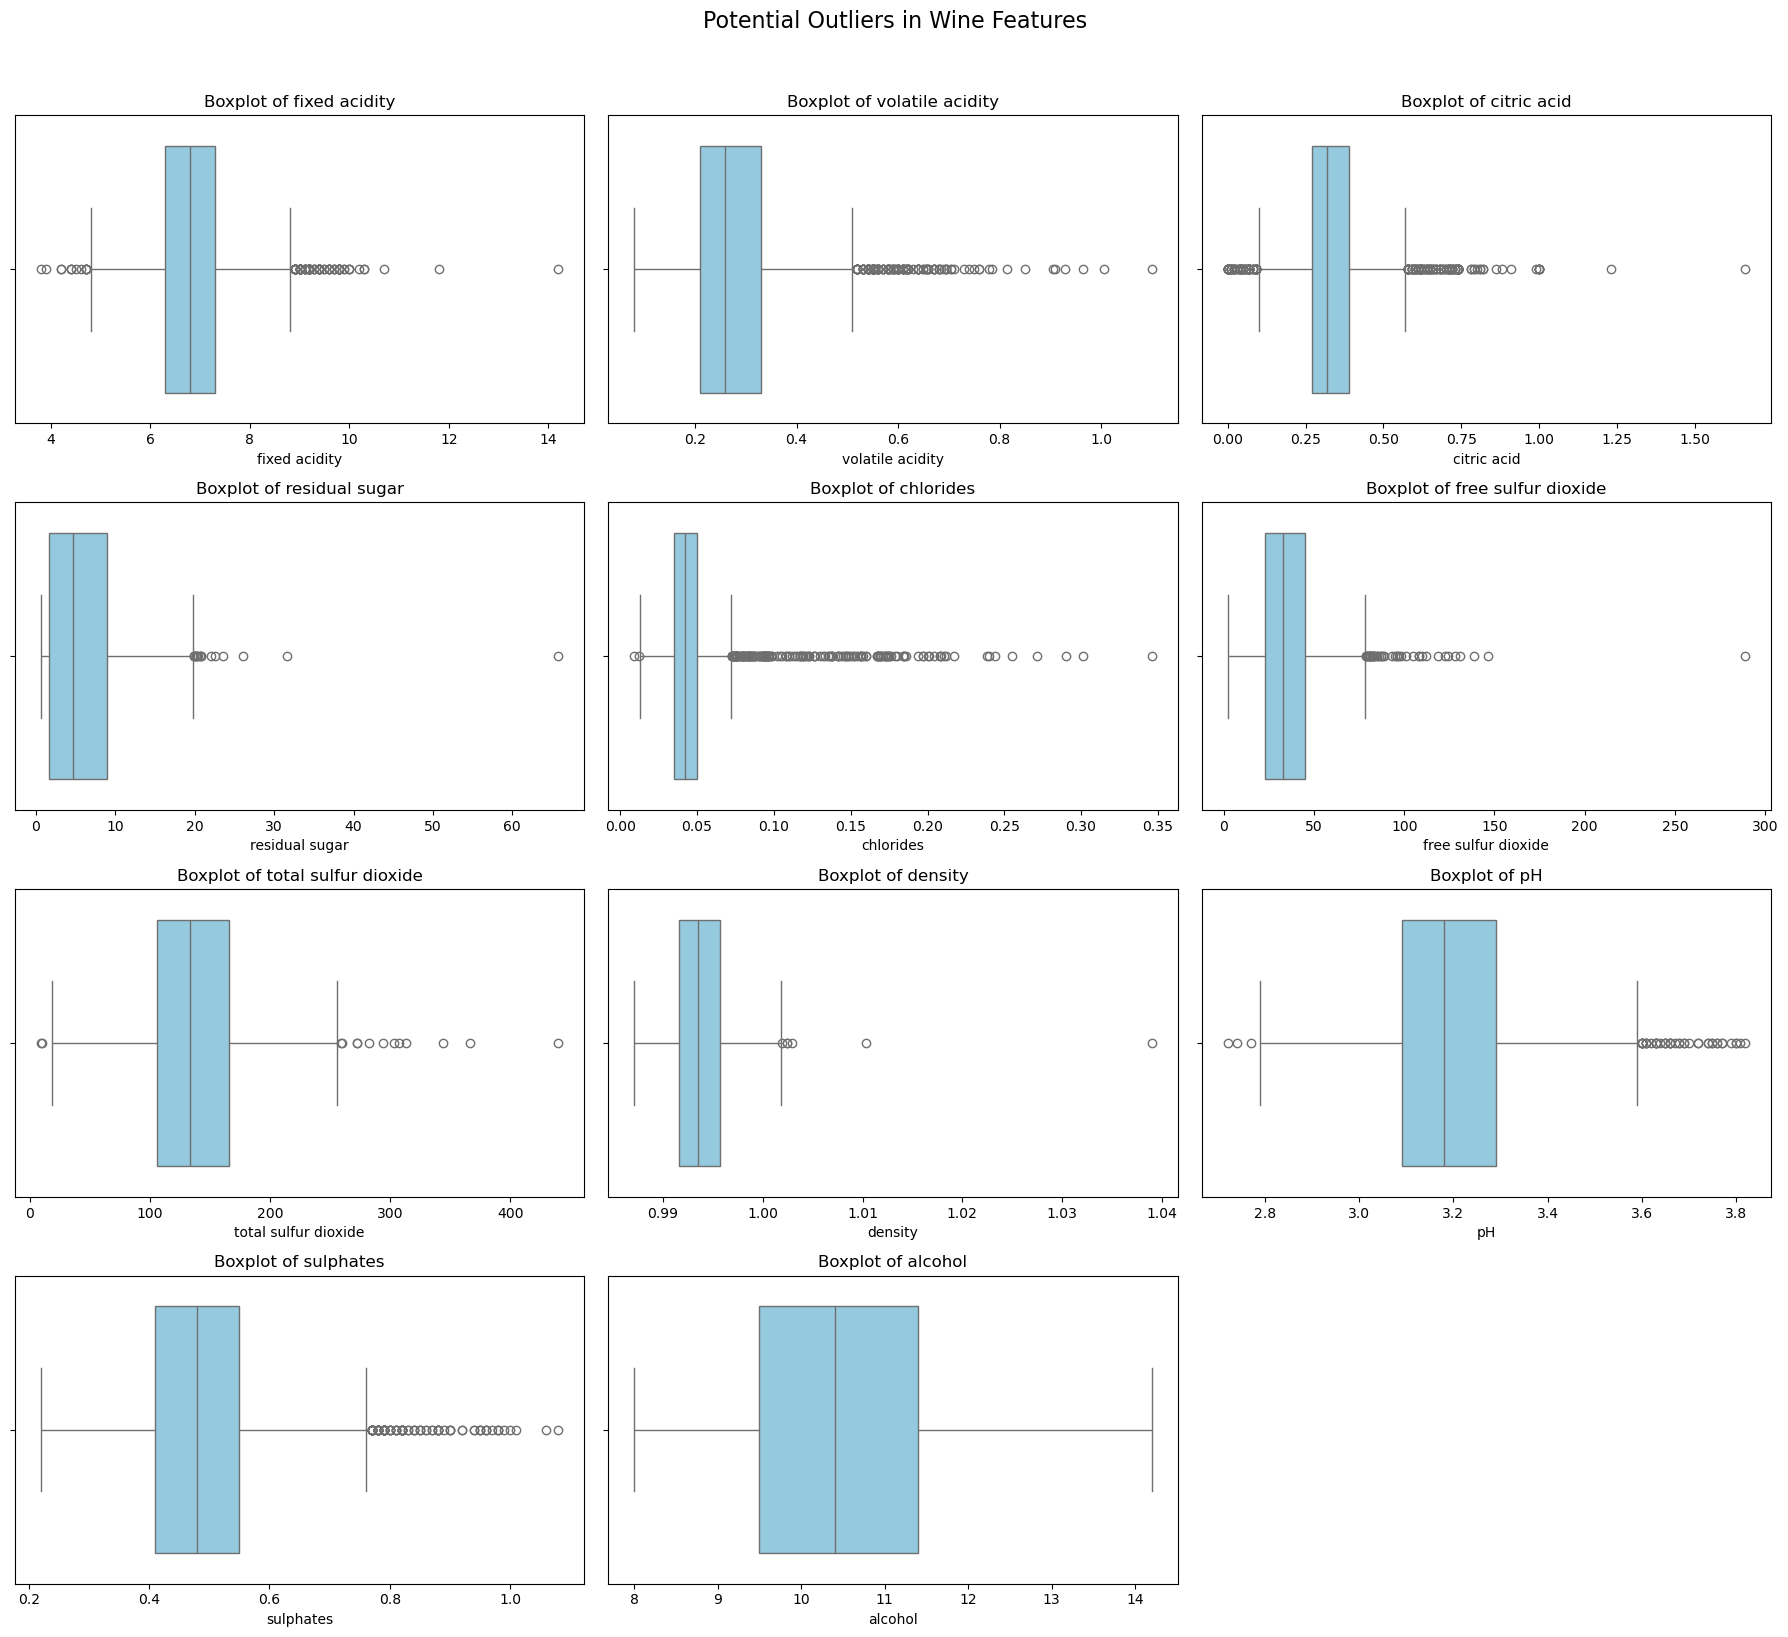

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the 11 predictor variables
feature_columns = wine_df.drop(
    columns=["quality", "quality_class"]
).columns

# Create a subplot containing 4 rows and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

# Convert the two-dimensional axes into a one-dimensional list
axes = axes.flatten()

# Create one boxplot for each predictor variable
for index, column in enumerate(feature_columns):
    sns.boxplot(
        x=wine_df[column],
        ax=axes[index],
        color="skyblue"
    )

    axes[index].set_title(f"Boxplot of {column}")
    axes[index].set_xlabel(column)

# Delete the unused twelfth subplot
for index in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[index])

plt.suptitle(
    "Potential Outliers in Wine Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Initial Interpretation of the Feature Boxplots

The boxplots indicate potential outliers in several physicochemical features. The most noticeable upper-tail observations appear in volatile acidity, citric acid, residual sugar, chlorides and free sulfur dioxide.

Some features, particularly residual sugar and chlorides, also appear positively skewed. A positively skewed distribution has a longer right tail because most observations are concentrated at lower values while a smaller number have much higher values.

However, the points outside the boxplot whiskers are not automatically data errors. Wine composition can naturally contain unusual but valid measurements. Removing all observations identified by the IQR rule could discard genuine wines, reduce the sample size and create selection bias.

Potential outliers may influence distance-based models such as KNN because the model calculates distances between observations. They may also affect `StandardScaler`, which uses the mean and standard deviation.

Therefore, no observations will be removed solely because they appear outside the boxplot whiskers. The potential outliers will first be quantified and checked for physical plausibility. Model performance can later be compared using standardization, normalization and, if justified, a robust preprocessing method.

In [10]:
outlier_summary = []

for column in feature_columns:
    Q1 = wine_df[column].quantile(0.25)
    Q3 = wine_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (wine_df[column] < lower_bound) |
        (wine_df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = outlier_count / len(wine_df) * 100

    outlier_summary.append({
        "feature": column,
        "lower_bound": round(lower_bound, 4),
        "upper_bound": round(upper_bound, 4),
        "potential_outliers": outlier_count,
        "percentage": round(outlier_percentage, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df.sort_values(
    "percentage",
    ascending=False
).reset_index(drop=True)

,feature,lower_bound,upper_bound,potential_outliers,percentage
0,citric acid,0.0900,0.5700,223,5.63
1,chlorides,0.0125,0.0725,178,4.49
2,volatile acidity,0.0300,0.5100,133,3.36
3,fixed acidity,4.8000,8.8000,106,2.68
4,sulphates,0.2000,0.7600,96,2.42
5,pH,2.7900,3.5900,46,1.16
6,free sulfur dioxide,-10.0000,78.0000,44,1.11
7,residual sugar,-9.3500,19.8500,16,0.40
8,total sulfur dioxide,16.0000,256.0000,14,0.35
9,density,0.9855,1.0018,6,0.15


### Quantitative Assessment of Potential Outliers

The IQR analysis identified potential outliers in 10 of the 11 predictor variables. Citric acid had the highest proportion at 5.63%, followed by chlorides at 4.49% and volatile acidity at 3.36%. Alcohol had no observations outside its calculated IQR boundaries.

The IQR method identifies observations using:

IQR = Q3 − Q1


\[
\]


\[
\text{Upper bound}=Q_3+1.5(IQR)
\]

These boundaries are statistical rules rather than scientific limits. For example, the lower IQR boundary for citric acid is 0.09. Consequently, chemically possible values between 0 and 0.09 may be labelled as potential outliers even though they are not necessarily errors.

Similarly, the calculated lower boundaries for residual sugar and free sulfur dioxide are negative. This does not indicate that negative observations exist; it only means that the mathematical boundary falls below the physically meaningful minimum of zero.

The potential outlier percentages for individual features range from 0% to 5.63%. These observations will be retained because there is currently no evidence that they represent measurement or data-entry errors.

Rather than deleting valid but unusual wines, the project will investigate skewness and compare preprocessing methods. This is particularly important for KNN because its distance calculation is sensitive to feature scale and extreme values.

The analysis therefore distinguishes between:

- a statistically unusual observation,
- a scientifically impossible observation,
- and an erroneous observation.

Only observations supported by evidence as erroneous or impossible should be removed.

## 6. Analysis of Feature Skewness

Skewness measures the asymmetry of a distribution.A simplified mathematical expression is: Skewness = (1/n) Σ ((xi − x̄) / s)³

where:

- \(n\) is the number of observations,
- \(x_i\) is an individual feature value,
- \(\bar{x}\) is the feature mean,
- \(s\) is the standard deviation.

The sign indicates the direction:

Skewness > 0 = longer right tail  
Skewness < 0 = longer left tail  
Skewness ≈ 0 = approximately symmetrical distribution


The following practical thresholds will guide interpretation:

Absolute skewness interpretation:

Below 0.5 = approximately symmetrical  
0.5 to below 1.0 = moderately skewed  
1.0 or above = strongly skewed


Skewness matters because extreme asymmetric values may affect distance-based models such as KNN and preprocessing methods based on the mean and standard deviation.

However, skewness does not automatically require transformation. Any transformation must be justified and later evaluated using model performance.

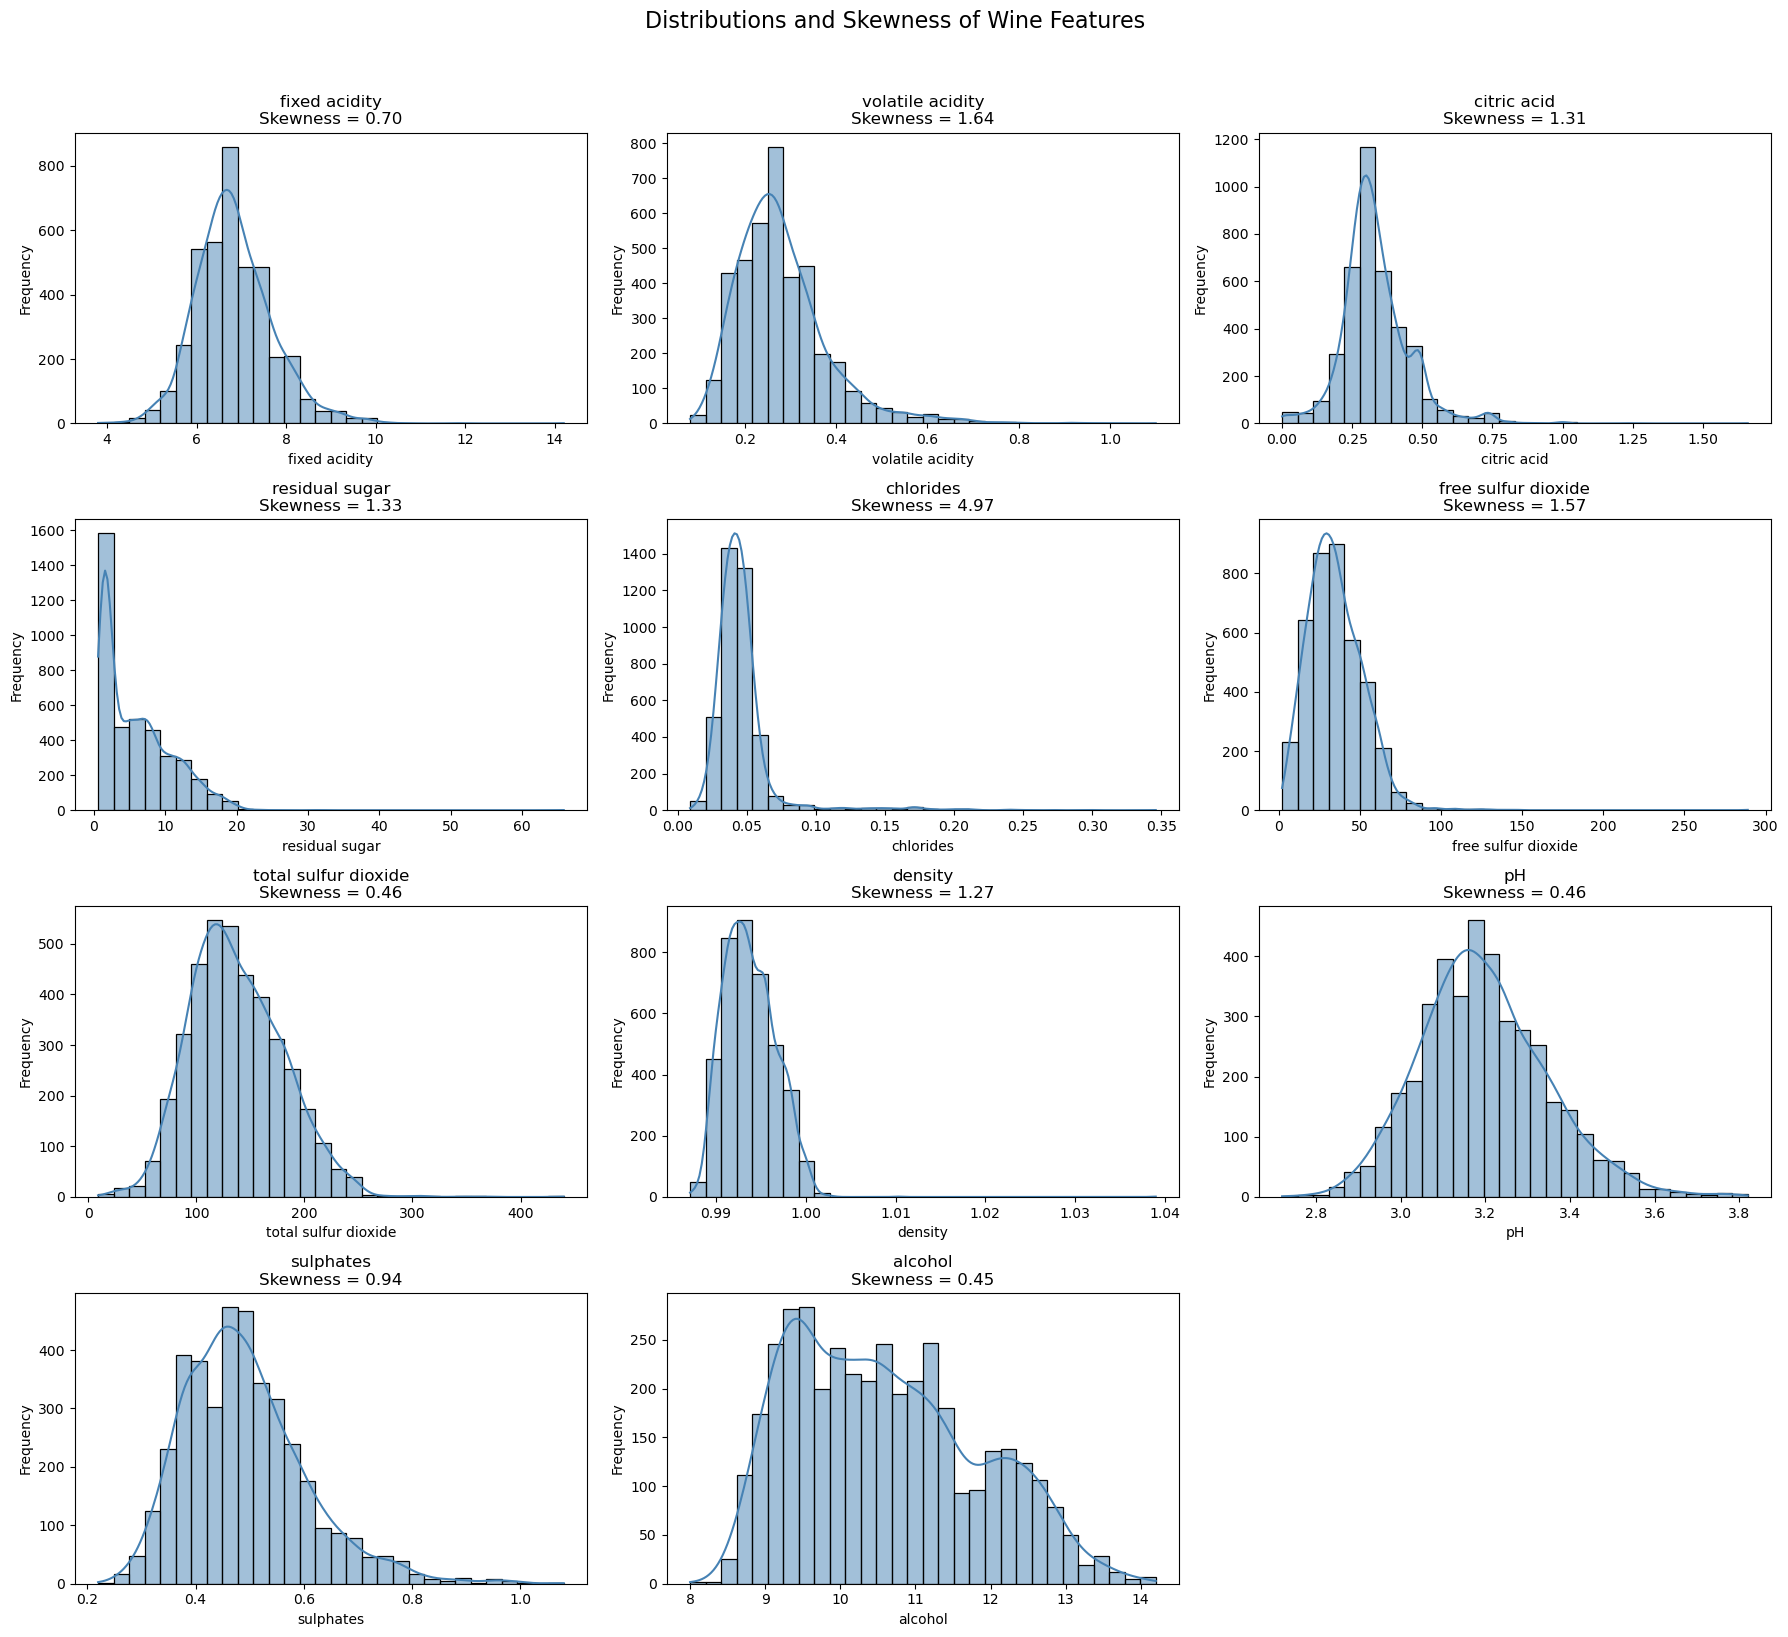

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the 11 predictor variables
feature_columns = wine_df.drop(
    columns=["quality", "quality_class"]
).columns

# Create a 4-row by 3-column subplot grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18, 16)
)

# Convert the 2-dimensional axes grid into a 1-dimensional array
axes = axes.flatten()

# Create one histogram with a KDE curve for each predictor
for index, column in enumerate(feature_columns):

    sns.histplot(
        data=wine_df,
        x=column,
        kde=True,
        bins=30,
        color="steelblue",
        ax=axes[index]
    )

    # Calculate the skewness of the current feature
    skew_value = wine_df[column].skew()

    axes[index].set_title(
        f"{column}\nSkewness = {skew_value:.2f}"
    )
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Frequency")

# Delete the unused twelfth subplot
for index in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[index])

plt.suptitle(
    "Distributions and Skewness of Wine Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [12]:
skewness_summary = (
    wine_df[feature_columns]
    .skew()
    .sort_values(ascending=False)
    .reset_index()
)

skewness_summary.columns = ["feature", "skewness"]

skewness_summary["absolute_skewness"] = (
    skewness_summary["skewness"].abs()
)

skewness_summary["interpretation"] = np.select(
    [
        skewness_summary["absolute_skewness"] < 0.5,
        skewness_summary["absolute_skewness"] < 1.0
    ],
    [
        "approximately symmetrical",
        "moderately skewed"
    ],
    default="strongly skewed"
)

skewness_summary

,feature,skewness,absolute_skewness,interpretation
0,chlorides,4.969076,4.969076,strongly skewed
1,volatile acidity,1.641081,1.641081,strongly skewed
2,free sulfur dioxide,1.566680,1.566680,strongly skewed
3,residual sugar,1.333639,1.333639,strongly skewed
4,citric acid,1.310601,1.310601,strongly skewed
5,density,1.273318,1.273318,strongly skewed
6,sulphates,0.937853,0.937853,moderately skewed
7,fixed acidity,0.696100,0.696100,moderately skewed
8,total sulfur dioxide,0.456800,0.456800,approximately symmetrical
9,pH,0.455457,0.455457,approximately symmetrical


### Interpretation of Feature Skewness

The skewness analysis shows that six predictor variables are strongly positively skewed:

- chlorides,
- volatile acidity,
- free sulfur dioxide,
- residual sugar,
- citric acid,
- and density.

Chlorides has the strongest skewness:

Skewness(chlorides) = 4.97


This indicates that most wines have relatively low chloride values, while a small number of wines have much higher values.

Two variables, sulphates and fixed acidity, are moderately positively skewed. Total sulfur dioxide, pH and alcohol are approximately symmetrical according to the selected threshold:

|Skewness| < 0.5


All calculated skewness values are positive. Therefore, the asymmetric distributions have longer right tails.

Strong skewness may influence K-Nearest Neighbors because extreme values can affect the calculated distances between observations. It may also influence standardization because the mean and standard deviation are sensitive to extreme values.

However, scaling and transformation are different operations:

- **Transformation** changes the shape of a distribution.
- **Scaling** changes the numerical range or scale.
- Standardization does not necessarily remove skewness.
- Min–max normalization does not remove skewness.

Standardization is calculated as:

z = (x − μtrain) / σtrain

where:

x = original feature value  
μ\_train = training-set mean  
σ\_train = training-set standard deviation  
z = standardized value

Min–max normalization is calculated as:

x′ = (x − xmin\_train) / (xmax\_train − xmin\_train)

Both scaling methods change the numerical scale but generally preserve the original distribution's skewness.

A power transformation, such as Yeo–Johnson, can be used to reduce skewness. Because it estimates transformation parameters from the data, it must be fitted only on the training set.

The project will therefore compare classification models using:

1. original unscaled features,
2. standardized features,
3. normalized features,
4. and transformed plus standardized features.

The train–test split will be performed before fitting any scaler or learned transformation. This prevents information from the test set from influencing preprocessing and avoids data leakage.


## 7. Defining the Features and Target

In supervised machine learning, the dataset is split into:

**X** = predictor variables/features  
**y** = target variable to be predicted

For this project:

**X** = physicochemical wine features, such as fixed acidity, volatile acidity, alcohol, and others

**y = quality\_class**

The original **quality** column is not included in **X** because **quality\_class** was created from it. Including it would cause **target leakage**, meaning the model would already have access to the answer.

The model relationship is:

**X → f(X) → ŷ**

where:

**X** = wine features  
**f** = classification model  
**ŷ** = predicted quality class

The feature matrix is:

**X ∈ R^(3961 × 11)**

This means there are **3,961 wine samples** and **11 predictor variables**.

The target vector is:

**y ∈ {0, 1}^3961**

where:

**y = 0** = lower-quality wine  
**y = 1** = acceptable or higher-quality wine


In [13]:
# X contains only the 11 physicochemical predictor variables
X = wine_df.drop(
    columns=["quality", "quality_class"]
)

# y contains the binary classification target
y = wine_df["quality_class"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Shape of X: (3961, 11)
Shape of y: (3961,)

Predictor columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target distribution:
quality_class
0    1348
1    2613
Name: count, dtype: int64




## 8. Stratified Train–Test Split

The dataset is divided into a training set and a test set:

**D = D\_train ∪ D\_test**

and:

**D\_train ∩ D\_test = ∅**

This means the training and test sets do not overlap.

An  **80/20 split** is used:

**80% = training data**  
**20% = test data**

The training set is used to fit preprocessing methods and train the model. The test set is kept unseen and used to evaluate model performance on new data.

Stratification is applied because the target classes are not perfectly balanced:

**P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k), where k ∈ {0, 1}**

This keeps the class proportions similar in the full dataset, training set, and test set.

**random\_state = 42** makes the split reproducible, so the same train-test split is produced each time.



P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k), where k ∈ {0, 1}

P = proportion  
P\_train = proportion in the training set  
P\_test = proportion in the test set  
P\_complete = proportion in the full dataset  
y = target variable  
k = class 0 or class 1  
y = k = observations in class k  
≈ = approximately equal



In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3168, 11)
X_test shape: (793, 11)
y_train shape: (3168,)
y_test shape: (793,)


In [15]:
class_proportion_check = pd.DataFrame({
    "complete_dataset": y.value_counts(normalize=True).sort_index(),
    "training_set": y_train.value_counts(normalize=True).sort_index(),
    "test_set": y_test.value_counts(normalize=True).sort_index()
}).mul(100).round(2)

class_proportion_check.index = [
    "Lower quality (0)",
    "Acceptable/higher quality (1)"
]

class_proportion_check

,complete_dataset,training_set,test_set
Lower quality (0),34.03,34.03,34.05
Acceptable/higher quality (1),65.97,65.97,65.95



**Verification of Stratification**

The class proportions after the split are very similar:

Lower quality (0): complete = 34.03%, train = 34.03%, test = 34.05%  
Acceptable/higher quality (1): complete = 65.97%, train = 65.97%, test = 65.95%

This confirms that stratification worked because the class proportions are approximately equal in the complete dataset, training set, and test set:

**P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k)**

The small difference of about 0.02 percentage points occurs because observations cannot be split into fractions. Therefore, `stratify=y` helped keep both quality classes represented fairly in training and testing.


In [16]:
# Combine the training features and target using their matching indices
training_analysis_df = X_train.copy()
training_analysis_df["quality_class"] = y_train

# Calculate the correlation of every feature with the target
target_correlations = (
    training_analysis_df
    .corr(numeric_only=True)[["quality_class"]]
    .drop(index="quality_class")
    .sort_values(
        by="quality_class",
        ascending=False
    )
)

target_correlations

,quality_class
alcohol,0.408307
pH,0.103115
sulphates,0.060480
citric acid,0.020544
free sulfur dioxide,0.007579
fixed acidity,-0.101552
residual sugar,-0.109196
total sulfur dioxide,-0.164865
chlorides,-0.186942
volatile acidity,-0.212550


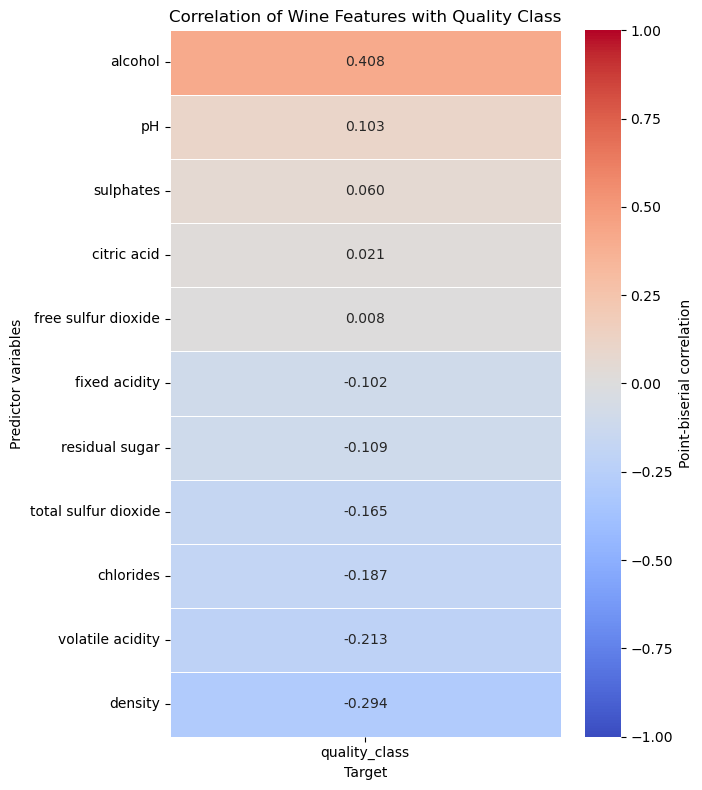

In [17]:
plt.figure(figsize=(7, 8))

sns.heatmap(
    target_correlations,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Point-biserial correlation"
    }
)

plt.title(
    "Correlation of Wine Features with Quality Class"
)
plt.xlabel("Target")
plt.ylabel("Predictor variables")

plt.tight_layout()
plt.show()

## Feature–Target Correlations

Most features have weak individual correlations with "quality_class", meaning no single physicochemical variable can clearly separate lower-quality wines from acceptable or higher-quality wines.

However, weak correlation does not mean a feature is useless. Correlation checks one feature at a time, while machine-learning models use all features together:

**ŷ = f(x1, x2, ..., x11)**


Because wine quality also depends partly on sensory judgement, similar wines may receive different scores. Therefore, perfect prediction is unrealistic.

For this reason, features are not removed only because they have weak correlations. Their usefulness is evaluated through trained classification models.


## 10. Majority-Class Baseline Model

Before training the real models, a `DummyClassifier` is used as a baseline. It provides a minimum performance reference.

The baseline does not use wine features such as alcohol, acidity, or sugar. It simply predicts the most common class in the training set for every wine.

Since class **1** is the majority class:

**ŷᵢ = 1 for every wine i**

Accuracy is calculated as:

**Accuracy = correct predictions / total predictions**

Because about **65.95%** of test wines are class **1**, the baseline accuracy is:

**Baseline test accuracy ≈ 65.95%**

This does not mean the model has learned useful patterns. It only performs well because class **1** is more common.

Therefore, trained models should:

* perform better than **65.95%**
* reach the project goal of at least **70% test accuracy**
* predict both class **0** and class **1**
* be evaluated using precision, recall, and the confusion matrix

The "DummyClassifier" is used only as a comparison benchmark, not as the final model.


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Create a baseline that always predicts the majority training class
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Fit the baseline using only the training data
baseline_model.fit(X_train, y_train)

# Generate predictions for training and test data
baseline_train_predictions = baseline_model.predict(X_train)
baseline_test_predictions = baseline_model.predict(X_test)

# Calculate training and test accuracy
baseline_train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

print(
    f"Baseline training accuracy: "
    f"{baseline_train_accuracy:.2%}"
)

print(
    f"Baseline test accuracy: "
    f"{baseline_test_accuracy:.2%}"
)

print(
    "Unique test predictions:",
    np.unique(baseline_test_predictions)
)

Baseline training accuracy: 65.97%
Baseline test accuracy: 65.95%
Unique test predictions: [1]




## 11. KNN Classification Model Before Scaling

The first machine-learning model is a **K-Nearest Neighbors (KNN)** classifier trained using the original, unscaled features.

The baseline model always predicted class **1** and achieved:

**Baseline test accuracy = 65.95%**

Unlike the baseline, KNN uses the **11 physicochemical features** to classify each wine.

For this model:

**k = 10**

This means KNN looks at the **10 nearest training wines** and predicts the most common class among them.

Distance is measured using Euclidean distance:

**d(x, z) = √Σ(xj − zj)²**

where:

**x and z** = two wines  
**p** = number of predictor variables  
**xj and zj** = values of feature j

The model is trained using:

**(X\_train, y\_train)**

and predicts the test classes using:

**X\_test → ŷ\_test**

This first model uses unscaled features. Its performance will later be compared with KNN after normalization.


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the unscaled KNN classifier
knn_unscaled = KNeighborsClassifier(
    n_neighbors=10
)

# Train only on the original training data
knn_unscaled.fit(
    X_train,
    y_train
)

# Make predictions on training and test data
y_train_pred_unscaled = knn_unscaled.predict(
    X_train
)

y_test_pred_unscaled = knn_unscaled.predict(
    X_test
)

# Calculate accuracy
train_accuracy_unscaled = accuracy_score(
    y_train,
    y_train_pred_unscaled
)

test_accuracy_unscaled = accuracy_score(
    y_test,
    y_test_pred_unscaled
)

# Calculate the generalization gap
generalization_gap_unscaled = (
    train_accuracy_unscaled
    - test_accuracy_unscaled
)

# Compare test accuracy with the baseline
improvement_over_baseline = (
    test_accuracy_unscaled
    - baseline_test_accuracy
)

print(
    f"Unscaled KNN training accuracy: "
    f"{train_accuracy_unscaled:.2%}"
)

print(
    f"Unscaled KNN test accuracy: "
    f"{test_accuracy_unscaled:.2%}"
)

print(
    f"Generalization gap: "
    f"{generalization_gap_unscaled:.2%}"
)

print(
    f"Improvement over baseline: "
    f"{improvement_over_baseline:.2%}"
)

Unscaled KNN training accuracy: 74.40%
Unscaled KNN test accuracy: 67.84%
Generalization gap: 6.56%
Improvement over baseline: 1.89%


 ### Interpretation of KNN Before Scaling

The unscaled KNN model achieved:

Training accuracy = 74.40%  
Test accuracy = 67.84%

It improved over the baseline by:

67.84% − 65.95% = 1.89 percentage points

This shows that the model learned some useful information from the features, but the improvement was small.

The generalization gap was:

74.40% − 67.84% = 6.56%

This means the model performed better on training data than on test data, suggesting some overfitting.


This indicates that the classifier performed better on the training data than on unseen test data. The difference suggests some overfitting.

The test accuracy also remained below the project objective:

\[
67.84\%<70\%
\]

Because KNN calculates distances and the predictor variables have different numerical scales, the unscaled result may be influenced disproportionately by variables with larger ranges, such as total sulfur dioxide.

The next step is to apply min–max normalization and retrain the same KNN model using the same value of \(k\). This provides a fair comparison in which only the feature scaling method changes.



 ### Confusion Matrix for KNN Before Scaling

A confusion matrix compares actual classes with predicted classes.

For binary classification:

**\[\[TN, FP], \[FN, TP]]**

where:

TN = class 0 correctly predicted as 0  
FP = class 0 incorrectly predicted as 1  
FN = class 1 incorrectly predicted as 0  
TP = class 1 correctly predicted as 1

Accuracy shows the overall correct predictions, while the confusion matrix shows how well the model predicts each class.


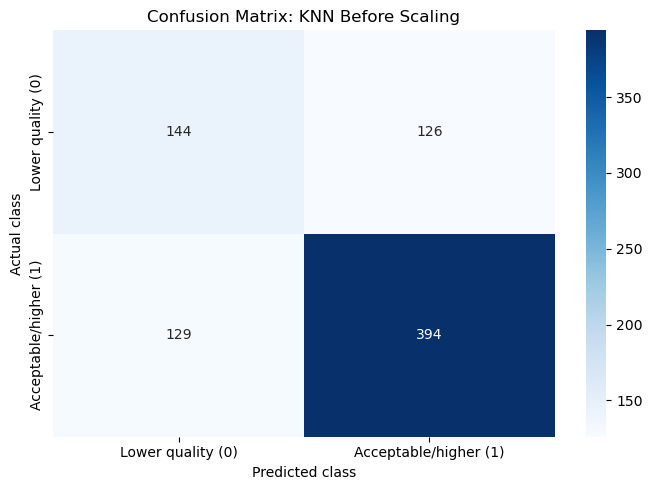

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
knn_unscaled_confusion = confusion_matrix(
    y_test,
    y_test_pred_unscaled
)

# Display it as a coloured heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_unscaled_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    yticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ]
)

plt.title("Confusion Matrix: KNN Before Scaling")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Create the min–max normalizer
minmax_scaler = MinMaxScaler()

# Learn training minima and maxima and normalize X_train
X_train_normalized = minmax_scaler.fit_transform(
    X_train
)

# Normalize X_test using the training parameters
X_test_normalized = minmax_scaler.transform(
    X_test
)

# Convert the results back into DataFrames
X_train_normalized = pd.DataFrame(
    X_train_normalized,
    columns=X_train.columns,
    index=X_train.index
)

X_test_normalized = pd.DataFrame(
    X_test_normalized,
    columns=X_test.columns,
    index=X_test.index
)

print("Normalized training shape:", X_train_normalized.shape)
print("Normalized test shape:", X_test_normalized.shape)

X_train_normalized.head()

Normalized training shape: (3168, 11)
Normalized test shape: (793, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3384,0.317308,0.356436,0.144578,0.032209,0.091988,0.076655,0.179070,0.029111,0.200000,0.186047,0.870968
3278,0.230769,0.148515,0.168675,0.177914,0.118694,0.181185,0.286047,0.155967,0.427273,0.174419,0.435484
2166,0.269231,0.257426,0.210843,0.082822,0.160237,0.101045,0.325581,0.159244,0.345455,0.290698,0.225806
3725,0.250000,0.287129,0.114458,0.059816,0.086053,0.118467,0.253488,0.084827,0.318182,0.232558,0.516129
1605,0.269231,0.158416,0.216867,0.115031,0.106825,0.181185,0.395349,0.167534,0.327273,0.232558,0.193548


In [ ]:
# Display the fitted scaler as a compact sklearn diagram
minmax_scaler

In [23]:
normalization_check = pd.DataFrame({
    "training_minimum": X_train_normalized.min(),
    "training_maximum": X_train_normalized.max()
}).round(3)

normalization_check

,training_minimum,training_maximum
fixed acidity,0.0,1.0
volatile acidity,0.0,1.0
citric acid,0.0,1.0
residual sugar,0.0,1.0
chlorides,0.0,1.0
free sulfur dioxide,0.0,1.0
total sulfur dioxide,0.0,1.0
density,0.0,1.0
pH,0.0,1.0
sulphates,0.0,1.0


### Verification of Min–Max Normalization

The normalization check confirms that every training feature has: \[
x'_{\min}=0
\]

and:

\[
x'_{\max}=1
\]

Therefore:

0 ≤ x′ ≤ 1


for all observations in the normalized training set.

This confirms that "MinMaxScaler" successfully placed all 11 predictor variables on the same numerical scale. Consequently, features with originally large values, such as total sulfur dioxide, can no longer dominate the KNN distance calculation merely because of their measurement range.

The test set was transformed using the minimum and maximum values learned from the training set. Test-set values are not guaranteed to remain strictly between 0 and 1 if a test observation falls outside the training range. This is acceptable because the test set was not used to fit the normalizer.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the normalized KNN model
knn_normalized = KNeighborsClassifier(
    n_neighbors=5
)

# Train only on the normalized training data
knn_normalized.fit(
    X_train_normalized,
    y_train
)

# Make predictions
y_train_pred_normalized = knn_normalized.predict(
    X_train_normalized
)

y_test_pred_normalized = knn_normalized.predict(
    X_test_normalized
)

# Calculate accuracy
train_accuracy_normalized = accuracy_score(
    y_train,
    y_train_pred_normalized
)

test_accuracy_normalized = accuracy_score(
    y_test,
    y_test_pred_normalized
)

# Calculate comparison measures
generalization_gap_normalized = (
    train_accuracy_normalized
    - test_accuracy_normalized
)

improvement_over_baseline_normalized = (
    test_accuracy_normalized
    - baseline_test_accuracy
)

change_from_unscaled = (
    test_accuracy_normalized
    - test_accuracy_unscaled
)

print(
    f"Normalized KNN training accuracy: "
    f"{train_accuracy_normalized:.2%}"
)

print(
    f"Normalized KNN test accuracy: "
    f"{test_accuracy_normalized:.2%}"
)

print(
    f"Generalization gap: "
    f"{generalization_gap_normalized:.2%}"
)

print(
    f"Improvement over baseline: "
    f"{improvement_over_baseline_normalized:.2%}"
)

print(
    f"Change from unscaled KNN: "
    f"{change_from_unscaled:.2%}"
)

Normalized KNN training accuracy: 82.80%
Normalized KNN test accuracy: 73.27%
Generalization gap: 9.53%
Improvement over baseline: 7.31%
Change from unscaled KNN: 5.42%


### Interpretation of KNN After Normalization

The KNN classifier trained with min–max normalized features achieved: Training accuracy = 82.80\%


Test accuracy = 73.27%

The model exceeded the project objective:73.27% > 70%


It also outperformed the majority-class baseline by approximately: 73.27% - 65.95% =7.32 percentage points. Compared with the unscaled KNN model, normalization increased test accuracy by: 73.27 % - 67.84 %= 5.43 percentage points.

This demonstrates that feature scaling materially improved KNN performance. Before normalization, predictors with large numerical ranges could dominate the Euclidean-distance calculation. After normalization, all predictors contributed on a comparable scale between 0 and 1.

However, the generalization gap was: 82.80 % - 73.27% = 9.53 percentage points

This indicates some overfitting because the model performs considerably better on the training data than on unseen test data. Therefore, although the model achieved the 70% objective, further evaluation and tuning are necessary.

Accuracy alone is also insufficient. The confusion matrix, precision and recall must be examined to determine whether the model can identify both quality classes.

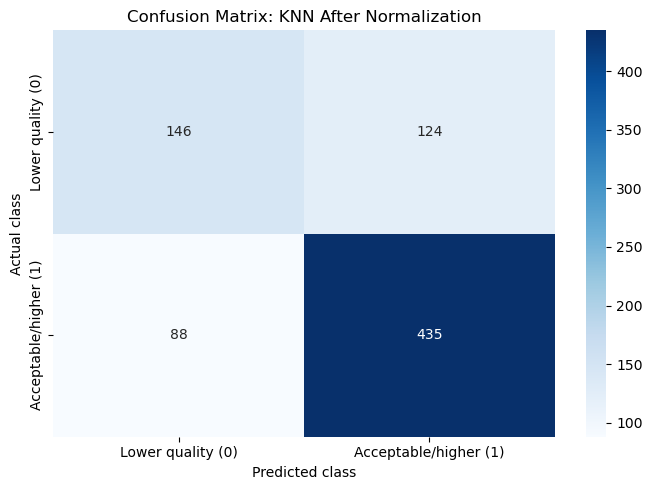

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

normalized_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred_normalized
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    normalized_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    yticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ]
)

plt.title("Confusion Matrix: KNN After Normalization")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.tight_layout()
plt.show()


### Interpretation of the Normalized KNN Confusion Matrix

The normalized KNN confusion matrix is: **\[\[146, 124], \[88, 435]]**

This means:

TN = 146 lower-quality wines correctly predicted as class 0  
FP = 124 lower-quality wines incorrectly predicted as class 1  
FN = 88 acceptable/higher-quality wines incorrectly predicted as class 0  
TP = 435 acceptable/higher-quality wines correctly predicted as class 1

Total test observations: 146 + 124 + 88 + 435 = 793

Correct predictions: 146 + 435 = 581

Test accuracy:

Accuracy = (TP + TN) / (TP + TN + FP + FN)  
Accuracy = (435 + 146) / 793 = 73.27%

Class 1 precision:

Precision = TP / (TP + FP)  
Precision = 435 / (435 + 124) ≈ 77.82%

Class 1 recall:

Recall = TP / (TP + FN)  
Recall = 435 / (435 + 88) ≈ 83.17%

Class 0 recall:

146 / (146 + 124) ≈ 54.07%

The model performs better at identifying acceptable/higher-quality wines than lower-quality wines. It achieved the 70% accuracy goal, but the 124 false positives show that more improvement is needed for detecting lower-quality wines.



 ### Classification Report for KNN After Normalization

The classification report evaluates the model for each class using precision, recall, and support.

Precision shows how reliable the model’s positive predictions are: **Precision = TP / (TP + FP)**

Recall shows how many actual observations of a class the model correctly identifies: **Recall = TP / (TP + FN)**

Support is the number of actual observations in each class.

Because the dataset is imbalanced, class-level results are important. Accuracy alone may hide weak performance on the minority class.


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred_normalized,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ]
    )
)

                               precision    recall  f1-score   support

            Lower quality (0)       0.62      0.54      0.58       270
Acceptable/higher quality (1)       0.78      0.83      0.80       523

                     accuracy                           0.73       793
                    macro avg       0.70      0.69      0.69       793
                 weighted avg       0.73      0.73      0.73       793




### Interpretation of the Normalized KNN Classification Report

The normalized KNN model achieved: **Accuracy = 73%**

This is higher than the baseline accuracy of **65.95%** and meets the project goal of **70%**.

For class 0, lower-quality wines: 
Precision₀ = 62%  
Recall₀ = 54%

This means the model correctly identifies only about **54%** of actual lower-quality wines, so many lower-quality wines are still classified as acceptable/higher quality.

For class 1, acceptable/higher-quality wines:

Precision₁ = 78%  
Recall₁ = 83%

This means the model performs better at identifying acceptable/higher-quality wines.

Support values:

n₀ = 270  
n₁ = 523

Because class 1 has more observations, the weighted averages are influenced more by class 1. The macro averages treat both classes equally:

Macro precision = 70%  
Macro recall = 69%

Overall, the normalized KNN model is a useful preliminary model because it reaches the accuracy target, but it still needs improvement in detecting lower-quality wines.


## 14. Hyperparameter Tuning of KNN Using Grid Search and Cross-Validation

The normalized KNN model achieved a test accuracy of **73.27%**, exceeding the majority-class baseline of **65.95%**. However, the value \(k=10\) was selected manually. Grid Search with Cross-Validation is now used to identify a better combination of KNN hyperparameters.

The parameters examined are:

- "n_neighbors": number of neighboring wines used for classification;
- "weights": whether all neighbors vote equally or closer neighbors receive more influence;
- "p": the distance formula used by KNN.

For Minkowski distance:

d(x,z)=(j=1∑m​∣xj​−zj​∣p)1/p

When \(p=1\), this becomes Manhattan distance:

d(x,z)=j=1∑m​∣xj​−zj​∣

When \(p=2\), it becomes Euclidean distance:

d(x, z) = √Σ(xj − zj)²


Five-fold stratified cross-validation divides the training data into five folds. The model is trained on four folds and validated on the remaining fold. This process is repeated five times:

Mean CV accuracy = (1 / 5) × Σ Accuracyᵢ, for i = 1 to 5


A pipeline combines normalization and KNN. During cross-validation, "MinMaxScaler" is fitted only on the training portion of each fold. This prevents validation-data leakage.

The test set is not involved in hyperparameter selection. It remains untouched until the best KNN configuration has been selected.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import set_config

# Display sklearn estimators using the coloured diagram
set_config(display="diagram")

knn_pipeline = Pipeline([
    ("normalizer", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

knn_pipeline

,steps,"[('normalizer', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [28]:
from sklearn.model_selection import ParameterGrid

knn_parameter_grid = {
    "knn__n_neighbors": list(range(3, 32)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

number_of_combinations = len(list(ParameterGrid(knn_parameter_grid)))

print("Number of hyperparameter combinations:", number_of_combinations)

Number of hyperparameter combinations: 116


### Stratified Five-Fold Cross-Validation

Five-fold cross-validation divides the training data into five sections called folds.

During each round:

- four folds are used to train the model;
- one fold is used to validate the model;
- a different fold becomes the validation fold in the next round.

The mean cross-validation accuracy is:

Accuracy_CV = (1 / 5) × Σᵢ₌₁⁵ Accuracyᵢ

Stratification preserves approximately the same proportions of lower-quality and acceptable/higher-quality wines in every fold:

Pfold​(y=k)≈Ptraining​(y=k),k∈{0,1}
Only the training set participates in cross-validation. The test set remains untouched until the best hyperparameters have been selected.

In [29]:
from sklearn.model_selection import StratifiedKFold

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [30]:
from sklearn.model_selection import GridSearchCV

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_parameter_grid,
    scoring="accuracy",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

knn_grid_search

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 4, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [31]:
knn_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 116 candidates, totalling 580 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 4, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [32]:
print("Best KNN hyperparameters:")
print(knn_grid_search.best_params_)

print(
    f"\nBest mean cross-validation accuracy: "
    f"{knn_grid_search.best_score_:.2%}"
)

Best KNN hyperparameters:
{'knn__n_neighbors': 23, 'knn__p': 1, 'knn__weights': 'distance'}

Best mean cross-validation accuracy: 77.24%


### Interpretation of the KNN Grid Search Result

Grid Search evaluated 116 hyperparameter combinations using five-fold stratified cross-validation. The best configuration was:

n_neighbors = 23
weights = "distance"
p = 1

The best mean cross-validation accuracy was:
Accuracy​ CV​=77.24%

The selected value \(k=23\) means that the model considers the 23 nearest training wines when predicting a wine's quality class.

Because "weights="distance", closer wines have greater influence than more distant wines. The approximate weight assigned to neighbour \(i\) is:

wi​=di​1​

The selected value \(p=1\) means that Manhattan distance is used:

d(x,z)=j=1∑m​∣xj​−zj​∣
This result indicates that a broader neighbourhood with stronger influence from nearby wines generalizes better than the manually selected KNN configuration according to cross-validation.

The cross-validation accuracy is not the final test accuracy. The tuned model must now be evaluated once on the untouched test set.

In [33]:
from sklearn.metrics import accuracy_score

# Retrieve the winning fitted pipeline
best_knn_model = knn_grid_search.best_estimator_

# Make predictions
y_train_pred_tuned_knn = best_knn_model.predict(X_train)
y_test_pred_tuned_knn = best_knn_model.predict(X_test)

# Calculate accuracy
tuned_knn_train_accuracy = accuracy_score(
    y_train, y_train_pred_tuned_knn
)

tuned_knn_test_accuracy = accuracy_score(
    y_test, y_test_pred_tuned_knn
)

tuned_knn_gap = (
    tuned_knn_train_accuracy - tuned_knn_test_accuracy
)

print(
    f"Tuned KNN training accuracy: "
    f"{tuned_knn_train_accuracy:.2%}"
)

print(
    f"Tuned KNN cross-validation accuracy: "
    f"{knn_grid_search.best_score_:.2%}"
)

print(
    f"Tuned KNN test accuracy: "
    f"{tuned_knn_test_accuracy:.2%}"
)

print(
    f"Generalization gap: "
    f"{tuned_knn_gap:.2%}"
)

Tuned KNN training accuracy: 100.00%
Tuned KNN cross-validation accuracy: 77.24%
Tuned KNN test accuracy: 75.16%
Generalization gap: 24.84%


### Interpretation of the Tuned KNN Performance

The tuned KNN model produced:

- training accuracy: **100.00%**;
- mean cross-validation accuracy: **77.24%**;
- test accuracy: **75.16%**;
- apparent training–test gap: **24.84 percentage points**.

The test accuracy exceeded the project objective of 70%:

\[
75.16\% > 70\%
\]

It also improved upon the manually configured normalized KNN:

\[
75.16\%-73.27\%=1.89] percentage points.

The selected model uses distance-weighted voting. When it predicts a training observation, that observation can be its own nearest neighbour with distance zero. This allows distance-weighted KNN to reproduce the training labels and explains the 100% training accuracy.

Therefore, the training accuracy is not a reliable estimate of performance on new wines. The cross-validation and test accuracies are more informative:

∣77.24%−75.16%∣=2.08 percentage points

The relatively small difference between cross-validation and test accuracy suggests that the cross-validation estimate transfers reasonably well to the untouched test set. Nevertheless, the perfect training accuracy shows that the distance-weighted KNN retains a strong capacity to memorize training observations.

The tuned KNN is therefore an improved candidate model, but it is not yet automatically the final model. It will be compared with ensemble classifiers such as Random Forest.

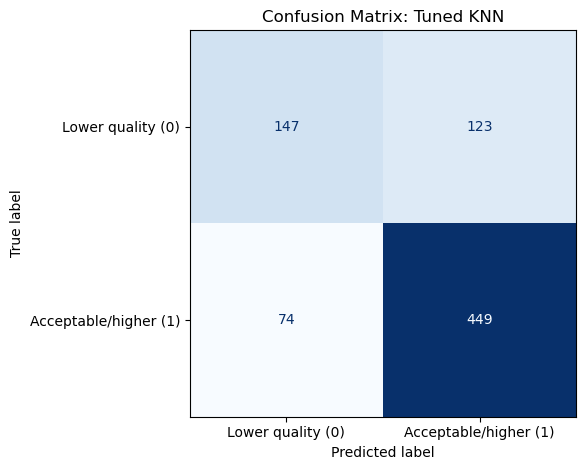

Classification report: Tuned KNN

                               precision    recall  f1-score   support

            Lower quality (0)       0.67      0.54      0.60       270
Acceptable/higher quality (1)       0.78      0.86      0.82       523

                     accuracy                           0.75       793
                    macro avg       0.73      0.70      0.71       793
                 weighted avg       0.74      0.75      0.74       793



In [34]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_tuned_knn,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix: Tuned KNN")
plt.tight_layout()
plt.show()

print("Classification report: Tuned KNN\n")

print(
    classification_report(
        y_test,
        y_test_pred_tuned_knn,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ],
        digits=2
    )
)

### Interpretation of the Tuned KNN Classification Report

The tuned KNN achieved a **test accuracy of 75.16%**. This means that the model correctly classified approximately **75 out of every 100 wines** in the unseen test dataset.

This result:

- exceeds the project objective of **70%**;
- exceeds the majority-class baseline of **65.95%**;
- improves upon the initial normalized KNN accuracy of **73.27%**.

The improvement over the initial normalized KNN is **1.89 percentage points**.

---

### Lower-Quality Wines — Class 0

The model achieved:

- **Precision: 67%**
- **Recall: 54%**
- **F1-score: 60%**

A precision of 67% means that when the model predicts a wine as lower quality, it is correct approximately 67% of the time.

A recall of 54% means that the model detects only 54% of all genuinely lower-quality wines. It misses approximately 46% of lower-quality wines by incorrectly classifying them as acceptable or higher quality.

The F1-score of 60% summarizes the balance between precision and recall for lower-quality wines.

---

### Acceptable/Higher-Quality Wines — Class 1

The model achieved:

- **Precision: 78%**
- **Recall: 86%**
- **F1-score: 82%**

A precision of 78% means that when the model predicts a wine as acceptable or higher quality, it is correct approximately 78% of the time.

A recall of 86% means that the model correctly detects 86% of all genuinely acceptable or higher-quality wines.

The F1-score of 82% shows that the model performs considerably better for acceptable/higher-quality wines than for lower-quality wines.

---

### Overall Interpretation

The macro-average F1-score is **71%**. This gives both classes equal importance regardless of their different sample sizes.

The weighted-average F1-score is **74%**. This considers the larger number of acceptable/higher-quality wines in the dataset.

Although tuning improved overall performance, the model remains better at identifying acceptable/higher-quality wines. Its main weakness is the relatively low recall of **54% for lower-quality wines**.

The tuned KNN is therefore a good candidate model, but it is not yet automatically the final model. It will next be compared with ensemble classifiers such as Random Forest.

## 15. Random Forest Classification

Random Forest is an ensemble classification model. An ensemble combines the predictions of multiple models instead of relying on only one model.

A Random Forest creates many decision trees. Each tree studies a slightly different sample of the training data and considers a random selection of features when creating its decisions.

For example, one tree might focus strongly on alcohol and density, while another tree might use volatile acidity, chlorides and sulphates.

Each tree predicts either:

- "0" — lower-quality wine; or
- "1" — acceptable/higher-quality wine.

The final Random Forest prediction is determined by the class receiving the most votes from the individual trees.

Random Forest is appropriate for this project because it:

- can identify nonlinear relationships;
- can combine information from several wine features;
- is less affected by differences in feature scale than KNN;
- is generally less sensitive to outliers;
- can estimate which features contribute most to its predictions;
- may provide better performance than a single model.

Unlike KNN, Random Forest does not calculate distances between observations. Min–max normalization is therefore not required.

The model will be trained using the original `X_train` and evaluated using the original `X_test`.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

set_config(display="diagram")

random_forest_initial = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_initial

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Training and Cross-Validating the Initial Random Forest

The initial Random Forest is evaluated using five-fold stratified cross-validation.

In each round, four folds are used to train the forest and one fold is used for validation. Stratification maintains approximately the same proportion of both wine-quality classes in every fold.

The test set is not used during this stage.

After cross-validation, the Random Forest is trained on the complete training set so it can later predict the untouched test observations.

In [38]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Cross-validation using only the training dataset
rf_cv_scores = cross_val_score(
    random_forest_initial,
    X_train,
    y_train,
    cv=stratified_cv,
    scoring="accuracy",
    n_jobs=-1
)

# Train the model on the complete training dataset
random_forest_initial.fit(X_train, y_train)

# Measure training accuracy
y_train_pred_rf = random_forest_initial.predict(X_train)

rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

print("Random Forest accuracy in each validation fold:")
print(np.round(rf_cv_scores, 4))

print(
    f"\nMean cross-validation accuracy: "
    f"{rf_cv_scores.mean():.2%}"
)

print(
    f"Cross-validation standard deviation: "
    f"{rf_cv_scores.std():.2%}"
)

print(
    f"Training accuracy: "
    f"{rf_train_accuracy:.2%}"
)

Random Forest accuracy in each validation fold:
[0.7697 0.7713 0.7713 0.7852 0.7615]

Mean cross-validation accuracy: 77.18%
Cross-validation standard deviation: 0.76%
Training accuracy: 100.00%


### Interpretation of Initial Random Forest Cross-Validation

The initial Random Forest produced validation accuracies between **76.15% and 78.52%** across the five folds.

Its mean cross-validation accuracy was **77.18%**. This is almost identical to the tuned KNN cross-validation accuracy of **77.24%**.

The cross-validation standard deviation was only **0.76%**. This small variation indicates that the Random Forest performed consistently across the five validation folds.

The training accuracy was **100%**, showing that the model fitted the training observations perfectly. However, perfect training accuracy does not mean that the model will classify all new wines correctly. It may indicate that the individual decision trees are too complex and have memorized details of the training data.

For this reason, cross-validation and test performance are more important than training accuracy.

The initial Random Forest shows promising and stable performance, but it must now be evaluated on the untouched test dataset. Later, Grid Search will be used to control tree complexity and reduce overfitting.

In [39]:
# Predict the untouched test dataset
y_test_pred_rf = random_forest_initial.predict(X_test)

# Calculate test accuracy
rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_rf
)

# Calculate performance differences
rf_generalization_gap = (
    rf_train_accuracy - rf_test_accuracy
)

rf_cv_test_difference = abs(
    rf_cv_scores.mean() - rf_test_accuracy
)

print(
    f"Initial Random Forest training accuracy: "
    f"{rf_train_accuracy:.2%}"
)

print(
    f"Initial Random Forest cross-validation accuracy: "
    f"{rf_cv_scores.mean():.2%}"
)

print(
    f"Initial Random Forest test accuracy: "
    f"{rf_test_accuracy:.2%}"
)

print(
    f"Training-test gap: "
    f"{rf_generalization_gap:.2%}"
)

print(
    f"Cross-validation-test difference: "
    f"{rf_cv_test_difference:.2%}"
)

Initial Random Forest training accuracy: 100.00%
Initial Random Forest cross-validation accuracy: 77.18%
Initial Random Forest test accuracy: 76.29%
Training-test gap: 23.71%
Cross-validation-test difference: 0.89%


### Interpretation of the Initial Random Forest Performance

The initial Random Forest achieved:

- training accuracy: **100.00%**;
- mean cross-validation accuracy: **77.18%**;
- test accuracy: **76.29%**.

The test result exceeds the project objective of 70% and the majority-class baseline of 65.95%.

The Random Forest also outperformed the tuned KNN on the test set:

**76.29% − 75.16% = 1.13 percentage points**

The difference between cross-validation and test accuracy was only **0.89 percentage points**. This indicates that cross-validation provided a reliable estimate of the model's performance on unseen wines.

However, the difference between training and test accuracy was **23.71 percentage points**. The 100% training accuracy indicates that the unrestricted decision trees fitted the training observations perfectly.

This suggests overfitting: the model learned the training dataset more closely than it could generalize to unseen wines.

The initial Random Forest is currently the strongest test model, but its tree complexity should be controlled through hyperparameter tuning.

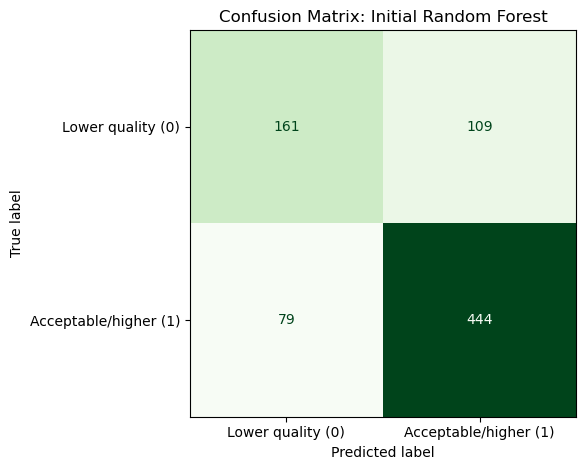

Classification report: Initial Random Forest

                               precision    recall  f1-score   support

            Lower quality (0)       0.67      0.60      0.63       270
Acceptable/higher quality (1)       0.80      0.85      0.83       523

                     accuracy                           0.76       793
                    macro avg       0.74      0.72      0.73       793
                 weighted avg       0.76      0.76      0.76       793



In [40]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    cmap="Greens",
    colorbar=False
)

plt.title("Confusion Matrix: Initial Random Forest")
plt.tight_layout()
plt.show()

print("Classification report: Initial Random Forest\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ],
        digits=2
    )
)

### Interpretation of the Initial Random Forest Classification Report

The initial Random Forest achieved a test accuracy of **76.29%**, making it the strongest model tested so far.

For lower-quality wines, the model achieved:

- Precision: **67%**
- Recall: **60%**
- F1-score: **63%**

A precision of 67% means that when the Random Forest predicts a wine as lower quality, it is correct approximately 67% of the time.

A recall of 60% means that the model detects 60% of all genuinely lower-quality wines. It misses approximately 40% of them.

Compared with tuned KNN, lower-quality recall improved from **54% to 60%**. This is an improvement of six percentage points.

For acceptable/higher-quality wines, the model achieved:

- Precision: **80%**
- Recall: **85%**
- F1-score: **83%**

This means that the model correctly detects approximately 85% of all acceptable/higher-quality wines.

The macro-average F1-score increased from **71% with tuned KNN to 73% with Random Forest**. Because macro averaging gives equal importance to both classes, this improvement shows that Random Forest provides a better balance between the two wine-quality classes.

The initial Random Forest therefore outperformed tuned KNN in:

- overall test accuracy;
- lower-quality recall;
- lower-quality F1-score;
- acceptable/higher-quality precision;
- and macro-average F1-score.

Although the initial Random Forest is currently the strongest model, its training accuracy of 100% indicates overfitting. Grid Search with cross-validation will therefore be used to control tree complexity and search for a better Random Forest configuration.

## 16. Random Forest Hyperparameter Tuning

The initial Random Forest achieved good test performance, but its 100% training accuracy indicated that the trees were too closely fitted to the training data.

Grid Search will now examine different settings that control:

- the number of decision trees;
- the maximum depth of each tree;
- the number of observations required to split a decision point;
- the minimum number of observations permitted at the end of a branch;
- and the number of features considered at each decision point.

Five-fold stratified cross-validation will be used to evaluate every configuration using only the training dataset.

The main objective is to find a Random Forest that:

- performs well on unseen wines;
- detects both quality classes;
- and reduces the difference between training and validation performance.

In [41]:
from sklearn.model_selection import ParameterGrid

rf_parameter_grid = {
    "n_estimators": [150, 250],
    "max_depth": [8, 12, 16],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_number_of_combinations = len(
    list(ParameterGrid(rf_parameter_grid))
)

print(
    "Number of Random Forest combinations:",
    rf_number_of_combinations
)

Number of Random Forest combinations: 72


### Creating the Random Forest Grid Search

Grid Search will evaluate all 72 Random Forest configurations using five-fold stratified cross-validation.

Each configuration will be trained and validated five times. The configuration with the highest mean validation accuracy will be selected.

The class-balancing setting is retained to give greater importance to the smaller lower-quality class.

Only the training dataset is used during Grid Search. The test dataset is not used to select the best hyperparameters.

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_for_tuning = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=rf_parameter_grid,
    scoring="accuracy",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

rf_grid_search

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [43]:
rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,250


In [44]:
print("Best Random Forest hyperparameters:")
print(rf_grid_search.best_params_)

print(
    f"\nBest mean cross-validation accuracy: "
    f"{rf_grid_search.best_score_:.2%}"
)

Best Random Forest hyperparameters:
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}

Best mean cross-validation accuracy: 77.15%


### Interpretation of the Best Random Forest Hyperparameters

Grid Search selected the following Random Forest configuration:

-  n_estimators = 250`
-  max_depth = 12`
-  max_features = sqrt
-  min_samples_split = 2
-  min_samples_leaf = 1

The model uses 250 decision trees. More trees generally make the combined prediction more stable, although they also increase computation time.

The maximum depth of each tree is limited to 12. This prevents the trees from growing without restriction and may reduce memorization of the training data.

The `sqrt` feature setting means that each decision point considers only a random subset of the 11 wine features. In this case, approximately three features are considered at each split.

The minimum split value of 2 means that a node containing at least two training observations may be divided.

The minimum leaf value of 1 means that a final branch may contain only one training observation. This still allows detailed trees, but the maximum depth of 12 limits their overall complexity.

The best mean cross-validation accuracy was **77.15%**. This is almost identical to the initial Random Forest cross-validation accuracy of **77.18%**.

The tuned model must now be evaluated to determine whether limiting tree depth reduces overfitting and maintains strong performance on unseen wines.

In [46]:
# Retrieve the fitted winning Random Forest
best_random_forest = rf_grid_search.best_estimator_

# Make training and test predictions
y_train_pred_tuned_rf = best_random_forest.predict(X_train)
y_test_pred_tuned_rf = best_random_forest.predict(X_test)

# Calculate accuracies
tuned_rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tuned_rf
)

tuned_rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned_rf
)

tuned_rf_gap = (
    tuned_rf_train_accuracy - tuned_rf_test_accuracy
)

tuned_rf_cv_test_difference = abs(
    rf_grid_search.best_score_ - tuned_rf_test_accuracy
)

print(
    f"Tuned Random Forest training accuracy: "
    f"{tuned_rf_train_accuracy:.2%}"
)

print(
    f"Tuned Random Forest cross-validation accuracy: "
    f"{rf_grid_search.best_score_:.2%}"
)

print(
    f"Tuned Random Forest test accuracy: "
    f"{tuned_rf_test_accuracy:.2%}"
)

print(
    f"Training-test gap: "
    f"{tuned_rf_gap:.2%}"
)

print(
    f"Cross-validation-test difference: "
    f"{tuned_rf_cv_test_difference:.2%}"
)

Tuned Random Forest training accuracy: 96.53%
Tuned Random Forest cross-validation accuracy: 77.15%
Tuned Random Forest test accuracy: 74.91%
Training-test gap: 21.62%
Cross-validation-test difference: 2.24%


### Interpretation of the Tuned Random Forest Performance

The tuned Random Forest achieved:

- training accuracy: **96.53%**;
- mean cross-validation accuracy: **77.15%**;
- test accuracy: **74.91%**.

Limiting the maximum tree depth reduced training accuracy from 100% to 96.53%. The training–test gap also decreased from 23.71 to 21.62 percentage points.

This shows that tuning reduced overfitting slightly.

However, test accuracy decreased from 76.29% for the initial Random Forest to 74.91% for the tuned Random Forest. This is a decrease of 1.38 percentage points.

The tuned model's cross-validation accuracy of 77.15% was almost identical to the initial model's 77.18%. The difference of only 0.03 percentage points is too small to represent a meaningful improvement.

This result demonstrates that hyperparameter tuning does not automatically produce better test performance. Grid Search selects the configuration that performs best across the training-validation folds, but that configuration is not guaranteed to achieve the highest score on one particular test set.

The initial Random Forest remains the strongest Random Forest version based on test accuracy. Nevertheless, the tuned model should also be assessed using precision, recall, F1-score and its confusion matrix before making a final decision.

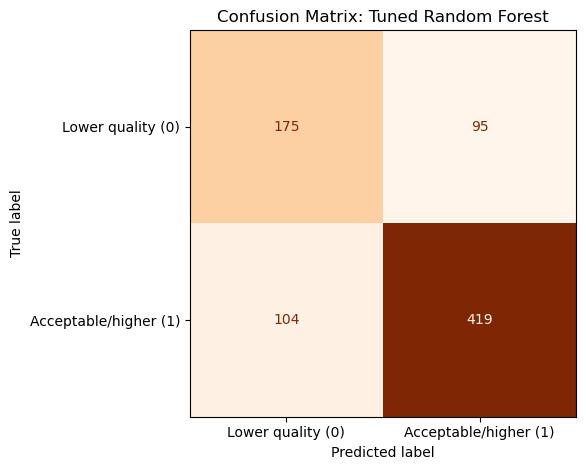

Classification report: Tuned Random Forest

                               precision    recall  f1-score   support

            Lower quality (0)       0.63      0.65      0.64       270
Acceptable/higher quality (1)       0.82      0.80      0.81       523

                     accuracy                           0.75       793
                    macro avg       0.72      0.72      0.72       793
                 weighted avg       0.75      0.75      0.75       793



In [47]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_tuned_rf,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    cmap="Oranges",
    colorbar=False
)

plt.title("Confusion Matrix: Tuned Random Forest")
plt.tight_layout()
plt.show()

print("Classification report: Tuned Random Forest\n")

print(
    classification_report(
        y_test,
        y_test_pred_tuned_rf,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ],
        digits=2
    )
)

### Interpretation of the Tuned Random Forest

The tuned Random Forest achieved a **test accuracy of 74.91%**. This exceeds the **70% project objective** and the **65.95% baseline accuracy**.

For lower-quality wines:

- Precision: **63%**
- Recall: **65%**
- F1-score: **64%**

The model correctly identified **65% of all lower-quality wines**. When it predicted that a wine was lower quality, it was correct **63% of the time**.

For acceptable or higher-quality wines:

- Precision: **82%**
- Recall: **80%**
- F1-score: **81%**

The model correctly identified **80% of all acceptable or higher-quality wines**. When it predicted this class, it was correct **82% of the time**.

### Effect of Hyperparameter Tuning

Compared with the initial Random Forest, tuning produced an important trade-off:

| Metric | Initial Random Forest | Tuned Random Forest |
|---|---:|---:|
| Test accuracy | 76.29% | 74.91% |
| Lower-quality precision | 67% | 63% |
| Lower-quality recall | 60% | 65% |
| Lower-quality F1-score | 63% | 64% |
| Higher-quality recall | 85% | 80% |
| Macro-average F1-score | 73% | 72% |

The tuned model improved lower-quality recall from **60% to 65%**. Therefore, it detects more genuinely lower-quality wines.

However, its overall test accuracy decreased from **76.29% to 74.91%**, and its performance on acceptable or higher-quality wines also decreased slightly.

Hyperparameter tuning does not guarantee a higher test accuracy. Grid Search selects the model with the best average cross-validation result from the supplied parameter combinations.

### Current Model Decision

- The **initial Random Forest** is currently the best model for overall test accuracy.
- The **tuned Random Forest** is more suitable when identifying lower-quality wines is especially important.
- Both Random Forest models exceeded the 70% project objective.
- The initial Random Forest will remain our leading model while additional ensemble models are investigated.

In [48]:
# Extract feature importance from the best-performing Random Forest
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest_initial.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
10,alcohol,0.160928
7,density,0.124112
1,volatile acidity,0.101161
5,free sulfur dioxide,0.100604
6,total sulfur dioxide,0.084732
4,chlorides,0.079992
3,residual sugar,0.075928
2,citric acid,0.074158
8,pH,0.071206
9,sulphates,0.065455


In [49]:
print(
    f"Total feature importance: "
    f"{feature_importance['importance'].sum():.2f}"
)

Total feature importance: 1.00


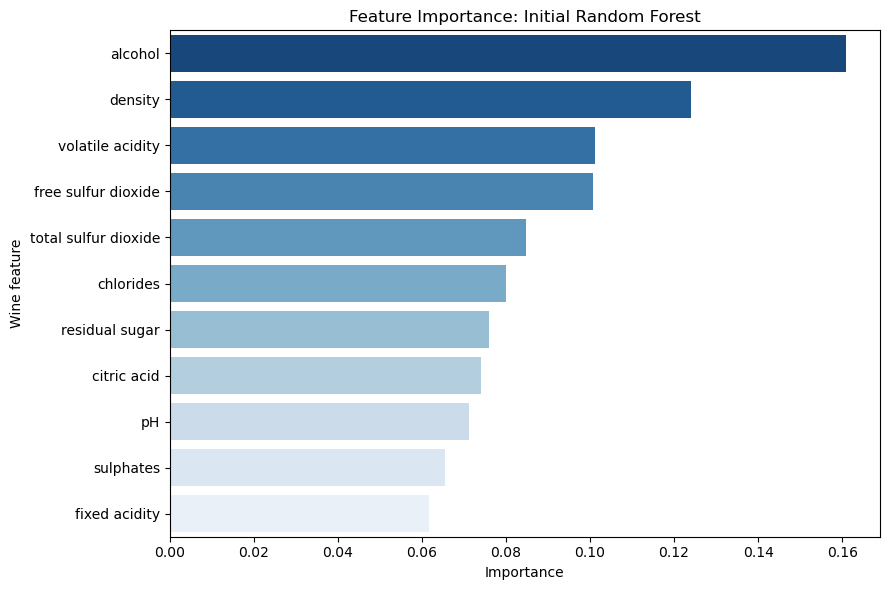

In [50]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature",
    hue="feature",
    palette="Blues_r",
    legend=False
)

plt.title("Feature Importance: Initial Random Forest")
plt.xlabel("Importance")
plt.ylabel("Wine feature")
plt.tight_layout()
plt.show()

### Interpretation of Random Forest Feature Importance

The Random Forest identified **alcohol** as the most influential feature for classifying white-wine quality. Its importance is approximately **16%**, making it noticeably more influential than the other predictors.

The next most important feature is **density**, with an importance of approximately **12%**.

Other influential features include:

- volatile acidity,
- free sulfur dioxide,
- total sulfur dioxide,
- and chlorides.

The features with the lowest importance in this model are:

- fixed acidity,
- sulphates,
- pH,
- and citric acid.

These results broadly support the earlier correlation analysis, where alcohol had the strongest positive relationship with wine quality and density had one of the strongest negative relationships.

However, feature importance and correlation do not mean exactly the same thing. Correlation examines a direct relationship between two variables, whereas Random Forest importance measures how useful a feature was across many decision-tree splits.

Feature importance also does not show the direction of the relationship. For example, this chart shows that alcohol is important, but it does not by itself state whether increasing alcohol raises or lowers the predicted quality class.

Therefore, the chart should be interpreted as showing **predictive usefulness**, not proof that a feature causes wine quality to change.

In [51]:
model_comparison = pd.DataFrame({
    "Model": [
        "Majority-class baseline",
        "Unscaled KNN (k=10)",
        "Normalized KNN (k=5)",
        "Tuned KNN",
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Training Accuracy (%)": [
        65.97,
        74.40,
        82.80,
        100.00,
        100.00,
        96.53
    ],
    "Cross-Validation Accuracy (%)": [
        None,
        None,
        None,
        77.24,
        77.18,
        77.15
    ],
    "Test Accuracy (%)": [
        65.95,
        67.84,
        73.27,
        75.16,
        76.29,
        74.91
    ]
})

model_comparison = model_comparison.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

model_comparison


,Model,Training Accuracy (%),Cross-Validation Accuracy (%),Test Accuracy (%)
0,Initial Random Forest,100.00,77.18,76.29
1,Tuned KNN,100.00,77.24,75.16
2,Tuned Random Forest,96.53,77.15,74.91
3,Normalized KNN (k=10),82.80,NaN,73.27
4,Unscaled KNN (k=10),74.40,NaN,67.84
5,Majority-class baseline,65.97,NaN,65.95


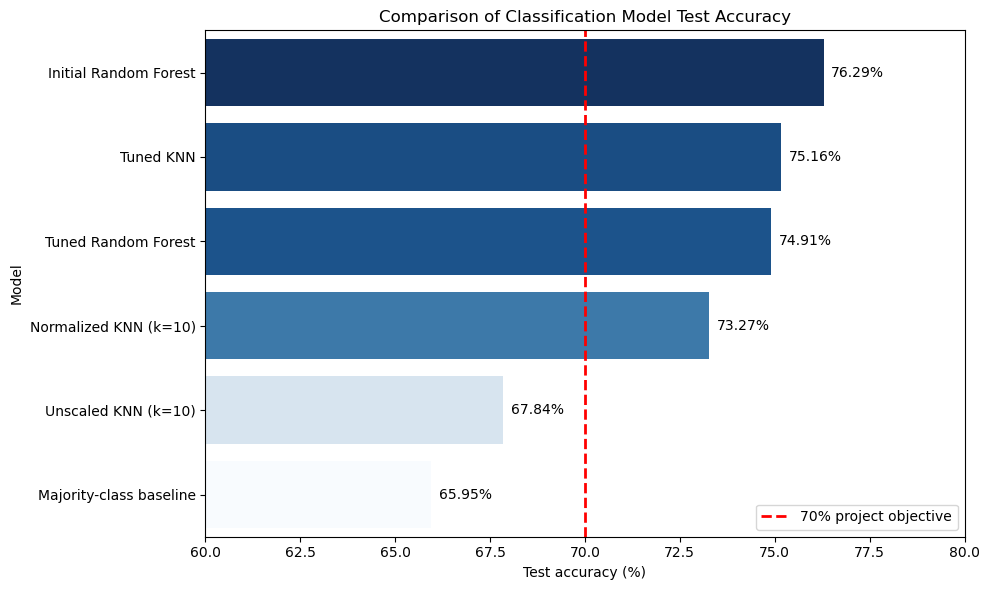

In [52]:
plt.figure(figsize=(10, 6))

comparison_plot = sns.barplot(
    data=model_comparison,
    x="Test Accuracy (%)",
    y="Model",
    hue="Test Accuracy (%)",
    palette="Blues",
    legend=False
)

# Project target
plt.axvline(
    x=70,
    color="red",
    linestyle="--",
    linewidth=2,
    label="70% project objective"
)

# Display each accuracy value
for bar in comparison_plot.patches:
    accuracy = bar.get_width()

    comparison_plot.text(
        accuracy + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2f}%",
        va="center"
    )

plt.title("Comparison of Classification Model Test Accuracy")
plt.xlabel("Test accuracy (%)")
plt.ylabel("Model")
plt.xlim(60, 80)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of Classification Models

The initial Random Forest currently has the highest test accuracy at **76.29%**.

The tuned KNN is the second-best model, with a test accuracy of **75.16%**, while the tuned Random Forest achieved **74.91%**.

The normalized KNN also exceeded the 70% project objective, achieving **73.27%**. In contrast, the unscaled KNN achieved only **67.84%**. This demonstrates that normalization was particularly important for KNN because KNN calculates distances between observations.

Random Forest did not require normalization because decision trees divide observations using feature thresholds rather than distances.

The tuned models did not automatically produce the highest test accuracy. Hyperparameter tuning selects the model that performs best across the cross-validation folds, but its performance on the untouched test set may still be slightly lower.

Based on overall test accuracy, the **initial Random Forest is currently the leading model**. However, the tuned Random Forest detected a larger proportion of lower-quality wines. Therefore, the final model choice depends on whether overall accuracy or detection of lower-quality wines is considered more important.

## Gradient Boosting Classification

Gradient Boosting is an ensemble-learning method that combines several small decision trees.

Unlike Random Forest, which builds many trees largely independently, Gradient Boosting builds trees sequentially. Each new tree attempts to correct classification errors remaining from the preceding trees.

The final prediction is based on the combined contribution of all the trees.

Three important Gradient Boosting hyperparameters are:

- **n_estimators:** the number of boosting trees.
- **learning_rate:** the contribution made by each new tree.
- **max_depth:** the maximum depth of each individual tree.

A smaller learning rate usually requires more trees. Deep trees can learn more complicated relationships but may also increase overfitting.

Gradient Boosting is based on decision trees and therefore does not require MinMax normalization. The original training features will be used.

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_initial = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_initial

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [54]:
from sklearn.model_selection import cross_val_score

gradient_boosting_cv_scores = cross_val_score(
    gradient_boosting_initial,
    X_train,
    y_train,
    cv=stratified_cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Gradient Boosting accuracy in each validation fold:")
print(np.round(gradient_boosting_cv_scores, 4))

print(
    f"\nMean cross-validation accuracy: "
    f"{gradient_boosting_cv_scores.mean() * 100:.2f}%"
)

print(
    f"Cross-validation standard deviation: "
    f"{gradient_boosting_cv_scores.std() * 100:.2f}%"
)

Gradient Boosting accuracy in each validation fold:
[0.7524 0.776  0.7666 0.7741 0.7804]

Mean cross-validation accuracy: 76.99%
Cross-validation standard deviation: 0.98%


In [55]:
from sklearn.metrics import accuracy_score

# Train on the complete training set
gradient_boosting_initial.fit(X_train, y_train)

# Predictions
y_train_pred_gb = gradient_boosting_initial.predict(X_train)
y_test_pred_gb = gradient_boosting_initial.predict(X_test)

# Accuracy results
gb_training_accuracy = accuracy_score(
    y_train,
    y_train_pred_gb
)

gb_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_gb
)

gb_cv_accuracy = gradient_boosting_cv_scores.mean()

# Comparisons
gb_training_test_gap = (
    gb_training_accuracy - gb_test_accuracy
)

gb_cv_test_difference = abs(
    gb_cv_accuracy - gb_test_accuracy
)

print(
    f"Initial Gradient Boosting training accuracy: "
    f"{gb_training_accuracy * 100:.2f}%"
)

print(
    f"Initial Gradient Boosting cross-validation accuracy: "
    f"{gb_cv_accuracy * 100:.2f}%"
)

print(
    f"Initial Gradient Boosting test accuracy: "
    f"{gb_test_accuracy * 100:.2f}%"
)

print(
    f"Training-test gap: "
    f"{gb_training_test_gap * 100:.2f}%"
)

print(
    f"Cross-validation-test difference: "
    f"{gb_cv_test_difference * 100:.2f}%"
)

Initial Gradient Boosting training accuracy: 82.26%
Initial Gradient Boosting cross-validation accuracy: 76.99%
Initial Gradient Boosting test accuracy: 76.42%
Training-test gap: 5.84%
Cross-validation-test difference: 0.57%


### Interpretation of the Initial Gradient Boosting Results

The initial Gradient Boosting classifier achieved:

- Training accuracy: **82.26%**
- Mean cross-validation accuracy: **76.99%**
- Test accuracy: **76.42%**
- Training-test gap: **5.84 percentage points**
- Cross-validation-test difference: **0.57 percentage points**

The test accuracy of **76.42%** exceeds the 70% project objective and is slightly higher than the **76.29%** achieved by the initial Random Forest.

The training-test gap is only **5.84 percentage points**. This is substantially smaller than the gap observed for Random Forest and tuned KNN. Therefore, Gradient Boosting shows much less evidence of memorizing the training data.

The cross-validation and test results are also very close:

- Cross-validation accuracy: **76.99%**
- Test accuracy: **76.42%**

The difference is only **0.57 percentage points**. This suggests that the test result is consistent with the model's performance across the validation folds.

Gradient Boosting is therefore the strongest model tested so far because it combines:

- the highest test accuracy,
- stable cross-validation performance,
- and a relatively small training-test gap.

However, the improvement over the initial Random Forest is only **0.13 percentage points**. Therefore, the classification report must also be examined before making a final model decision.

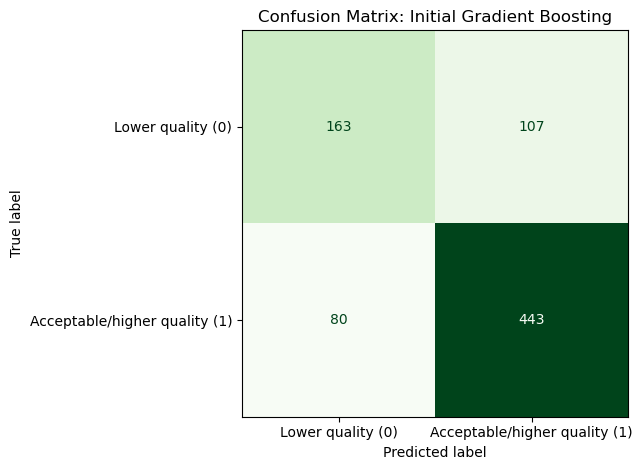

Classification report: Initial Gradient Boosting

                               precision    recall  f1-score   support

            Lower quality (0)       0.67      0.60      0.64       270
Acceptable/higher quality (1)       0.81      0.85      0.83       523

                     accuracy                           0.76       793
                    macro avg       0.74      0.73      0.73       793
                 weighted avg       0.76      0.76      0.76       793



In [56]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_gb,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher quality (1)"
    ],
    cmap="Greens",
    colorbar=False
)

plt.title("Confusion Matrix: Initial Gradient Boosting")
plt.tight_layout()
plt.show()

print("Classification report: Initial Gradient Boosting\n")

print(
    classification_report(
        y_test,
        y_test_pred_gb,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ]
    )
)

## Hyperparameter Tuning of Gradient Boosting

The initial Gradient Boosting model achieved a test accuracy of **76.42%** with a relatively small training-test gap.

Grid Search will now test different combinations of Gradient Boosting hyperparameters using five-fold stratified cross-validation.

The hyperparameters being tested are:

- **n_estimators:** number of sequential trees.
- **learning_rate:** contribution made by each new tree.
- **max_depth:** maximum depth of each tree.
- **min_samples_leaf:** minimum number of training observations required in a terminal leaf.
- **subsample:** proportion of training observations used to build each tree.

Using a subsample below 1.0 introduces randomness and may help reduce overfitting.

The untouched test set will not be used during Grid Search.

In [57]:
from sklearn.model_selection import ParameterGrid

gradient_boosting_parameter_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 3],
    "subsample": [0.8, 1.0]
}

number_of_gb_combinations = len(
    list(ParameterGrid(gradient_boosting_parameter_grid))
)

print(
    "Number of Gradient Boosting combinations:",
    number_of_gb_combinations
)

Number of Gradient Boosting combinations: 72


In [58]:
from sklearn.model_selection import GridSearchCV

gradient_boosting_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gradient_boosting_parameter_grid,
    scoring="accuracy",
    cv=stratified_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gradient_boosting_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 3], 'n_estimators': [100, 150, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'log_loss'


In [59]:
print("Best Gradient Boosting hyperparameters:")
print(gradient_boosting_grid_search.best_params_)

print(
    f"\nBest mean cross-validation accuracy: "
    f"{gradient_boosting_grid_search.best_score_ * 100:.2f}%"
)

Best Gradient Boosting hyperparameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200, 'subsample': 1.0}

Best mean cross-validation accuracy: 77.43%


In [60]:
# Retrieve the complete model selected by Grid Search
gradient_boosting_tuned = (
    gradient_boosting_grid_search.best_estimator_
)

# Make predictions
y_train_pred_tuned_gb = gradient_boosting_tuned.predict(
    X_train
)

y_test_pred_tuned_gb = gradient_boosting_tuned.predict(
    X_test
)

# Calculate accuracy
tuned_gb_training_accuracy = accuracy_score(
    y_train,
    y_train_pred_tuned_gb
)

tuned_gb_cv_accuracy = (
    gradient_boosting_grid_search.best_score_
)

tuned_gb_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_tuned_gb
)

# Calculate performance differences
tuned_gb_training_test_gap = (
    tuned_gb_training_accuracy -
    tuned_gb_test_accuracy
)

tuned_gb_cv_test_difference = abs(
    tuned_gb_cv_accuracy -
    tuned_gb_test_accuracy
)

print(
    f"Tuned Gradient Boosting training accuracy: "
    f"{tuned_gb_training_accuracy * 100:.2f}%"
)

print(
    f"Tuned Gradient Boosting cross-validation accuracy: "
    f"{tuned_gb_cv_accuracy * 100:.2f}%"
)

print(
    f"Tuned Gradient Boosting test accuracy: "
    f"{tuned_gb_test_accuracy * 100:.2f}%"
)

print(
    f"Training-test gap: "
    f"{tuned_gb_training_test_gap * 100:.2f}%"
)

print(
    f"Cross-validation-test difference: "
    f"{tuned_gb_cv_test_difference * 100:.2f}%"
)

Tuned Gradient Boosting training accuracy: 85.98%
Tuned Gradient Boosting cross-validation accuracy: 77.43%
Tuned Gradient Boosting test accuracy: 76.67%
Training-test gap: 9.31%
Cross-validation-test difference: 0.76%


### Systematic Evaluation of Lower-Quality Wines

Overall accuracy alone is insufficient because approximately 66% of the wines belong to the acceptable/higher-quality class.

A model could achieve a relatively high accuracy while performing poorly when identifying lower-quality wines.

The systematic review will therefore focus on:

- **Lower-quality recall:** the percentage of all genuinely lower-quality wines detected by the model.
- **Lower-quality precision:** the percentage of lower-quality predictions that were correct.
- **Lower-quality F1-score:** the balance between lower-quality precision and recall.
- **False negatives for class 0:** lower-quality wines incorrectly classified as acceptable or higher quality.

This is important in a quality-control setting because incorrectly accepting a lower-quality wine could be more costly than incorrectly rejecting an acceptable wine.

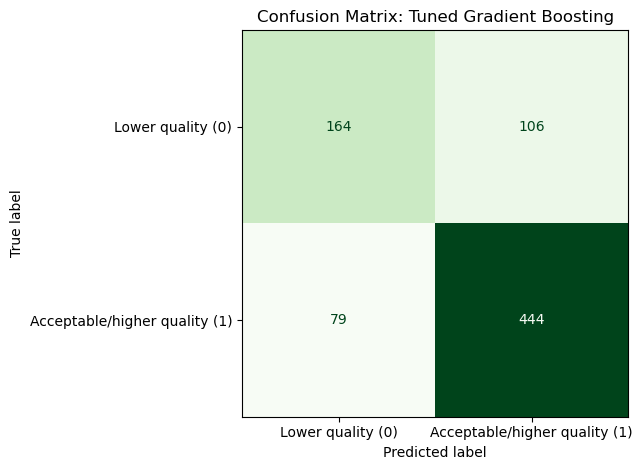

Classification report: Tuned Gradient Boosting

                               precision    recall  f1-score   support

            Lower quality (0)       0.67      0.61      0.64       270
Acceptable/higher quality (1)       0.81      0.85      0.83       523

                     accuracy                           0.77       793
                    macro avg       0.74      0.73      0.73       793
                 weighted avg       0.76      0.77      0.76       793



In [61]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_tuned_gb,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher quality (1)"
    ],
    cmap="Greens",
    colorbar=False
)

plt.title("Confusion Matrix: Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

print("Classification report: Tuned Gradient Boosting\n")

print(
    classification_report(
        y_test,
        y_test_pred_tuned_gb,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ]
    )
)

In [62]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Set pos_label=0 because lower quality is class 0
lower_quality_precision_gb = precision_score(
    y_test,
    y_test_pred_tuned_gb,
    pos_label=0
)

lower_quality_recall_gb = recall_score(
    y_test,
    y_test_pred_tuned_gb,
    pos_label=0
)

lower_quality_f1_gb = f1_score(
    y_test,
    y_test_pred_tuned_gb,
    pos_label=0
)

print(
    f"Lower-quality precision: "
    f"{lower_quality_precision_gb * 100:.2f}%"
)

print(
    f"Lower-quality recall: "
    f"{lower_quality_recall_gb * 100:.2f}%"
)

print(
    f"Lower-quality F1-score: "
    f"{lower_quality_f1_gb * 100:.2f}%"
)

Lower-quality precision: 67.49%
Lower-quality recall: 60.74%
Lower-quality F1-score: 63.94%


In [63]:
# Calculate class-0 metrics for the initial Gradient Boosting model
initial_gb_precision_0 = precision_score(
    y_test,
    y_test_pred_gb,
    pos_label=0
)

initial_gb_recall_0 = recall_score(
    y_test,
    y_test_pred_gb,
    pos_label=0
)

initial_gb_f1_0 = f1_score(
    y_test,
    y_test_pred_gb,
    pos_label=0
)

lower_quality_comparison = pd.DataFrame({
    "Model": [
        "Normalized KNN (k=5)",
        "Tuned KNN",
        "Initial Random Forest",
        "Tuned Random Forest",
        "Initial Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "Test Accuracy (%)": [
        73.27,
        75.16,
        76.29,
        74.91,
        76.42,
        76.67
    ],
    "Lower-quality Precision (%)": [
        62.00,
        67.00,
        67.00,
        63.00,
        initial_gb_precision_0 * 100,
        lower_quality_precision_gb * 100
    ],
    "Lower-quality Recall (%)": [
        54.00,
        54.00,
        60.00,
        65.00,
        initial_gb_recall_0 * 100,
        lower_quality_recall_gb * 100
    ],
    "Lower-quality F1-score (%)": [
        58.00,
        60.00,
        63.00,
        64.00,
        initial_gb_f1_0 * 100,
        lower_quality_f1_gb * 100
    ]
})

lower_quality_comparison = lower_quality_comparison.round(2)

lower_quality_comparison.sort_values(
    by="Lower-quality Recall (%)",
    ascending=False
).reset_index(drop=True)

,Model,Test Accuracy (%),Lower-quality Precision (%),Lower-quality Recall (%),Lower-quality F1-score (%)
0,Tuned Random Forest,74.91,63.00,65.00,64.00
1,Tuned Gradient Boosting,76.67,67.49,60.74,63.94
2,Initial Gradient Boosting,76.42,67.08,60.37,63.55
3,Initial Random Forest,76.29,67.00,60.00,63.00
4,Normalized KNN (k=10),73.27,62.00,54.00,58.00
5,Tuned KNN,75.16,67.00,54.00,60.00


### Interpretation of Lower-Quality Wine Detection

The models were compared systematically using lower-quality precision, recall and F1-score.

Lower-quality recall is especially important for quality control because it measures how many genuinely lower-quality wines the model successfully detects.

The tuned Random Forest achieved the highest lower-quality recall at approximately **65%**. This means it missed fewer lower-quality wines than the other models.

The tuned Gradient Boosting achieved lower-quality recall of **60.74%**, but it produced the highest overall test accuracy at **76.67%**.

The lower-quality F1-scores of the tuned Random Forest and tuned Gradient Boosting are both approximately **64%**. Their ability to balance precision and recall for lower-quality wines is therefore very similar.

The preferred model depends on the business objective:

- If the priority is the highest overall classification accuracy, tuned Gradient Boosting is preferred.
- If the priority is detecting as many lower-quality wines as possible, tuned Random Forest is preferred.
- For a balanced final choice, tuned Gradient Boosting currently offers the strongest combination of overall accuracy, stable validation performance and lower-quality detection.

The model-selection decision should therefore consider both statistical performance and the practical cost of classification errors.

### Final Interpretation of Lower-Quality Wine Performance

The systematic comparison reveals a trade-off between overall accuracy and the detection of lower-quality wines.

The **tuned Random Forest** achieved the highest lower-quality recall at **65%**. This means that it detected approximately 65 out of every 100 genuinely lower-quality wines. However, its overall test accuracy was lower at **74.91%**.

The **tuned Gradient Boosting** achieved the highest overall test accuracy at **76.67%**. Its lower-quality recall was **60.74%**, meaning that it detected approximately 61 out of every 100 lower-quality wines.

Compared with tuned Gradient Boosting, tuned Random Forest gained approximately **4.26 percentage points** in lower-quality recall but lost approximately **1.76 percentage points** in overall accuracy.

The lower-quality F1-scores were almost identical:

- Tuned Random Forest: **64.00%**
- Tuned Gradient Boosting: **63.94%**

This means both models provided a very similar balance between lower-quality precision and recall.

The initial Gradient Boosting and initial Random Forest also produced very similar lower-quality results. However, the tuned Gradient Boosting achieved the highest overall accuracy and showed stable cross-validation performance.

### Model Selection Decision

The preferred model depends on the practical objective:

- **Best overall accuracy:** Tuned Gradient Boosting
- **Best lower-quality recall:** Tuned Random Forest
- **Best balanced final candidate:** Tuned Gradient Boosting

The tuned Gradient Boosting is selected as the current final model because it achieved:

- the highest test accuracy at **76.67%**,
- the highest cross-validation accuracy among the ensemble models at **77.43%**,
- lower-quality precision of **67.49%**,
- and a lower-quality F1-score of **63.94%**.

However, if failing to detect a lower-quality wine is considered particularly costly, the tuned Random Forest would be the safer operational choice because of its higher lower-quality recall.

## Decision-Threshold Tuning

Classification models normally use a probability threshold of 0.50.

- Probability of class 1 at least 0.50: predict acceptable/higher quality.
- Probability of class 1 below 0.50: predict lower quality.

Increasing the threshold makes it more difficult for a wine to be classified as acceptable or higher quality. This may detect more lower-quality wines, but it can also incorrectly reject more acceptable wines.

The threshold will be selected using cross-validated predictions from the training set. The untouched test set will not be used to choose the threshold.

Balanced accuracy will be used during threshold selection because it gives equal importance to recall for both quality classes.

In [64]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Produce out-of-fold probabilities using training data only
gb_oof_probabilities = cross_val_predict(
    gradient_boosting_tuned,
    X_train,
    y_train,
    cv=stratified_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [65]:
threshold_results = []

for threshold in np.arange(0.40, 0.71, 0.01):

    # Predict class 1 only when its probability reaches the threshold
    oof_predictions = (
        gb_oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Balanced Accuracy (%)":
            balanced_accuracy_score(
                y_train,
                oof_predictions
            ) * 100,

        "Lower-quality Precision (%)":
            precision_score(
                y_train,
                oof_predictions,
                pos_label=0
            ) * 100,

        "Lower-quality Recall (%)":
            recall_score(
                y_train,
                oof_predictions,
                pos_label=0
            ) * 100,

        "Lower-quality F1-score (%)":
            f1_score(
                y_train,
                oof_predictions,
                pos_label=0
            ) * 100
    })

threshold_results = pd.DataFrame(
    threshold_results
).round(2)

threshold_results

,Threshold,Balanced Accuracy (%),Lower-quality Precision (%),Lower-quality Recall (%),Lower-quality F1-score (%)
0,0.40,69.75,72.24,49.26,58.58
1,0.41,69.95,71.41,50.28,59.01
2,0.42,70.27,71.08,51.30,59.59
3,0.43,70.56,70.54,52.41,60.14
4,0.44,71.02,70.49,53.62,60.91
5,0.45,71.55,70.69,54.82,61.76
6,0.46,71.72,69.79,55.94,62.10
7,0.47,72.39,69.85,57.61,63.14
8,0.48,72.55,69.43,58.35,63.41
9,0.49,73.26,69.53,60.11,64.48


In [66]:
best_threshold_result = threshold_results.loc[
    threshold_results[
        "Balanced Accuracy (%)"
    ].idxmax()
]

best_threshold = best_threshold_result["Threshold"]

print("Best threshold based on training cross-validation:")
print(best_threshold_result)

Best threshold based on training cross-validation:
Threshold                       0.68
Balanced Accuracy (%)          75.54
Lower-quality Precision (%)    60.80
Lower-quality Recall (%)       76.53
Lower-quality F1-score (%)     67.76
Name: 28, dtype: float64


In [67]:
from sklearn.metrics import accuracy_score

# Obtain class-1 probabilities for the untouched test set
gb_test_probabilities = gradient_boosting_tuned.predict_proba(
    X_test
)[:, 1]

# Convert probabilities into classes using threshold 0.68
y_test_pred_threshold_gb = (
    gb_test_probabilities >= best_threshold
).astype(int)

# Calculate test metrics
threshold_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_threshold_gb
)

threshold_test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_test_pred_threshold_gb
)

threshold_test_precision_0 = precision_score(
    y_test,
    y_test_pred_threshold_gb,
    pos_label=0
)

threshold_test_recall_0 = recall_score(
    y_test,
    y_test_pred_threshold_gb,
    pos_label=0
)

threshold_test_f1_0 = f1_score(
    y_test,
    y_test_pred_threshold_gb,
    pos_label=0
)

print(f"Selected threshold: {best_threshold:.2f}")

print(
    f"Threshold-adjusted test accuracy: "
    f"{threshold_test_accuracy * 100:.2f}%"
)

print(
    f"Threshold-adjusted balanced accuracy: "
    f"{threshold_test_balanced_accuracy * 100:.2f}%"
)

print(
    f"Lower-quality precision: "
    f"{threshold_test_precision_0 * 100:.2f}%"
)

print(
    f"Lower-quality recall: "
    f"{threshold_test_recall_0 * 100:.2f}%"
)

print(
    f"Lower-quality F1-score: "
    f"{threshold_test_f1_0 * 100:.2f}%"
)

Selected threshold: 0.68
Threshold-adjusted test accuracy: 71.88%
Threshold-adjusted balanced accuracy: 73.04%
Lower-quality precision: 56.40%
Lower-quality recall: 76.67%
Lower-quality F1-score: 64.99%


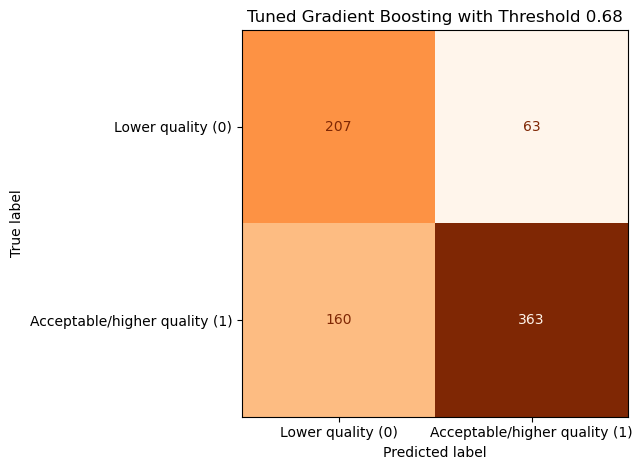

                               precision    recall  f1-score   support

            Lower quality (0)       0.56      0.77      0.65       270
Acceptable/higher quality (1)       0.85      0.69      0.77       523

                     accuracy                           0.72       793
                    macro avg       0.71      0.73      0.71       793
                 weighted avg       0.75      0.72      0.73       793



In [68]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_threshold_gb,
    display_labels=[
        "Lower quality (0)",
        "Acceptable/higher quality (1)"
    ],
    cmap="Oranges",
    colorbar=False
)

plt.title(
    "Tuned Gradient Boosting with Threshold 0.68"
)
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test,
        y_test_pred_threshold_gb,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ]
    )
)

### Interpretation of Threshold Adjustment

Using a decision threshold of 0.68 substantially improved the model's ability to detect lower-quality wines.

Lower-quality recall increased to **77%**. This means that the model detected approximately 77 out of every 100 genuinely lower-quality wines.

However, lower-quality precision decreased to **56%**. Therefore, some acceptable or higher-quality wines were incorrectly classified as lower quality.

Overall accuracy decreased from **76.67% with the default threshold to approximately 72% with the adjusted threshold**.

This demonstrates the trade-off between overall accuracy and lower-quality detection:

- The default threshold provides higher overall accuracy.
- The adjusted threshold detects considerably more lower-quality wines.
- Both versions exceed the 70% project objective.

The tuned Gradient Boosting model with the default threshold is selected as the final general-purpose model because it achieved the highest overall accuracy.

The threshold-adjusted version is retained as a quality-control alternative when failing to detect a lower-quality wine is considered particularly costly.

## Confidence Intervals for the Final Model

A performance value calculated from one test set is an estimate rather than a guaranteed value for every future dataset.

Bootstrap resampling repeatedly samples observations from the test results and recalculates the selected metric. The resulting distribution is used to estimate a 95% confidence interval.

Confidence intervals will be calculated for:

- overall test accuracy,
- and lower-quality recall.

The confidence interval communicates the uncertainty surrounding the final model's measured performance.

In [69]:
from sklearn.utils import resample

random_generator = np.random.default_rng(42)
number_of_bootstrap_samples = 2000

bootstrap_accuracies = []
bootstrap_lower_quality_recalls = []

y_test_array = np.asarray(y_test)
y_prediction_array = np.asarray(y_test_pred_tuned_gb)

for _ in range(number_of_bootstrap_samples):

    bootstrap_indices = random_generator.choice(
        len(y_test_array),
        size=len(y_test_array),
        replace=True
    )

    y_bootstrap = y_test_array[bootstrap_indices]
    predictions_bootstrap = y_prediction_array[
        bootstrap_indices
    ]

    bootstrap_accuracies.append(
        accuracy_score(
            y_bootstrap,
            predictions_bootstrap
        )
    )

    # Only calculate recall when class 0 is present
    if 0 in y_bootstrap:
        bootstrap_lower_quality_recalls.append(
            recall_score(
                y_bootstrap,
                predictions_bootstrap,
                pos_label=0
            )
        )

accuracy_ci_lower, accuracy_ci_upper = np.percentile(
    bootstrap_accuracies,
    [2.5, 97.5]
)

recall_ci_lower, recall_ci_upper = np.percentile(
    bootstrap_lower_quality_recalls,
    [2.5, 97.5]
)

print(
    f"Final-model test accuracy: "
    f"{tuned_gb_test_accuracy * 100:.2f}%"
)

print(
    f"95% confidence interval for accuracy: "
    f"{accuracy_ci_lower * 100:.2f}% to "
    f"{accuracy_ci_upper * 100:.2f}%"
)

print(
    f"\nLower-quality recall: "
    f"{lower_quality_recall_gb * 100:.2f}%"
)

print(
    f"95% confidence interval for lower-quality recall: "
    f"{recall_ci_lower * 100:.2f}% to "
    f"{recall_ci_upper * 100:.2f}%"
)

Final-model test accuracy: 76.67%
95% confidence interval for accuracy: 73.52% to 79.57%

Lower-quality recall: 60.74%
95% confidence interval for lower-quality recall: 54.58% to 66.30%


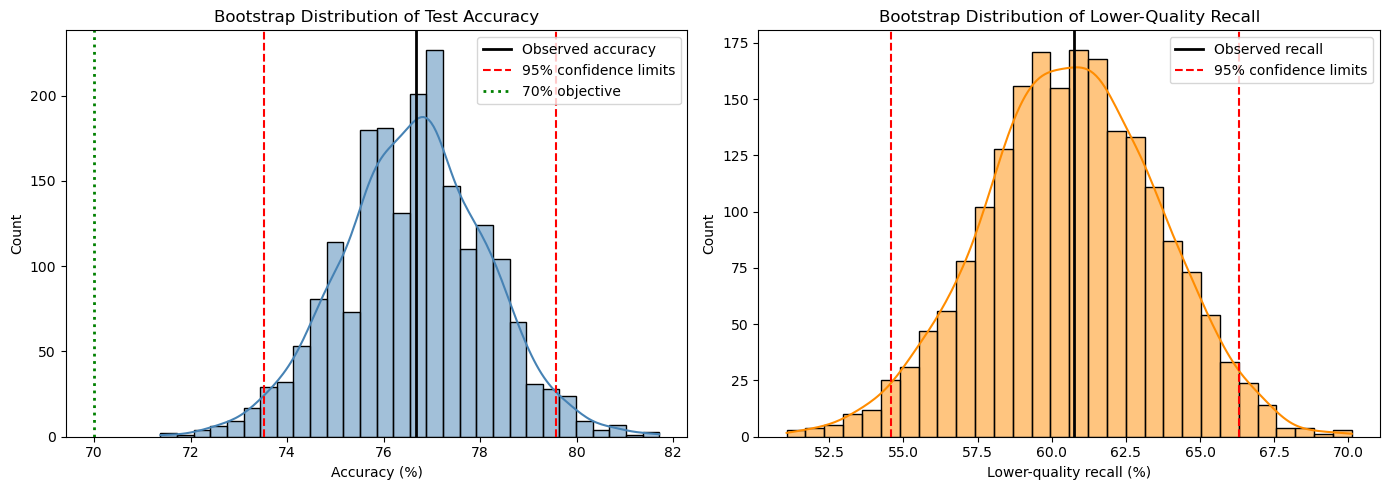

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy distribution
sns.histplot(
    np.array(bootstrap_accuracies) * 100,
    bins=30,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].axvline(
    tuned_gb_test_accuracy * 100,
    color="black",
    linewidth=2,
    label="Observed accuracy"
)

axes[0].axvline(
    accuracy_ci_lower * 100,
    color="red",
    linestyle="--",
    label="95% confidence limits"
)

axes[0].axvline(
    accuracy_ci_upper * 100,
    color="red",
    linestyle="--"
)

axes[0].axvline(
    70,
    color="green",
    linestyle=":",
    linewidth=2,
    label="70% objective"
)

axes[0].set_title("Bootstrap Distribution of Test Accuracy")
axes[0].set_xlabel("Accuracy (%)")
axes[0].legend()

# Lower-quality recall distribution
sns.histplot(
    np.array(bootstrap_lower_quality_recalls) * 100,
    bins=30,
    kde=True,
    color="darkorange",
    ax=axes[1]
)

axes[1].axvline(
    lower_quality_recall_gb * 100,
    color="black",
    linewidth=2,
    label="Observed recall"
)

axes[1].axvline(
    recall_ci_lower * 100,
    color="red",
    linestyle="--",
    label="95% confidence limits"
)

axes[1].axvline(
    recall_ci_upper * 100,
    color="red",
    linestyle="--"
)

axes[1].set_title(
    "Bootstrap Distribution of Lower-Quality Recall"
)

axes[1].set_xlabel("Lower-quality recall (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation of the 95% Confidence Intervals

The final Gradient Boosting model achieved an observed test accuracy of **76.67%**.

The bootstrap 95% confidence interval ranges from **73.52% to 79.57%**. The complete interval is above the project's 70% objective, providing evidence that the model's performance is meaningfully better than the required target.

Lower-quality recall was **60.74%**, with a 95% confidence interval from **54.58% to 66.30%**.

The lower-quality recall interval is wider because the test set contains fewer lower-quality wines. Estimates based on fewer observations generally contain greater uncertainty.

The intervals show that performance should not be presented as an exact guarantee. The observed values are estimates based on the available test sample.

The bootstrap intervals describe uncertainty for this dataset and evaluation procedure. External validation using wines from another producer, region or production period would be required before claiming that the model performs equally well in every real-world setting.

## Surrogate Model

The final Gradient Boosting classifier combines 200 sequential decision trees. Its complete decision process is therefore difficult to represent in one diagram.

A surrogate model is a simpler model trained to imitate the predictions of a more complex model.

In this project, a small Decision Tree is trained using:

- the original training features,
- and the final Gradient Boosting model's predictions as its target.

The surrogate is not intended to replace the Gradient Boosting model. Its purpose is to provide an understandable approximation of the final model's behaviour.

Surrogate fidelity measures how frequently the surrogate and final model produce the same prediction.

In [71]:
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

# Predictions made by the final model
final_model_train_predictions = (
    gradient_boosting_tuned.predict(X_train)
)

final_model_test_predictions = (
    gradient_boosting_tuned.predict(X_test)
)

# Small interpretable surrogate tree
surrogate_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=30,
    random_state=42
)

# Learn to imitate the final model
surrogate_model.fit(
    X_train,
    final_model_train_predictions
)

# Surrogate predictions
surrogate_train_predictions = surrogate_model.predict(
    X_train
)

surrogate_test_predictions = surrogate_model.predict(
    X_test
)

# Agreement with the Gradient Boosting model
surrogate_train_fidelity = accuracy_score(
    final_model_train_predictions,
    surrogate_train_predictions
)

surrogate_test_fidelity = accuracy_score(
    final_model_test_predictions,
    surrogate_test_predictions
)

# Accuracy against the real test target
surrogate_test_accuracy = accuracy_score(
    y_test,
    surrogate_test_predictions
)

print(
    f"Surrogate training fidelity: "
    f"{surrogate_train_fidelity * 100:.2f}%"
)

print(
    f"Surrogate test fidelity: "
    f"{surrogate_test_fidelity * 100:.2f}%"
)

print(
    f"Surrogate accuracy against actual classes: "
    f"{surrogate_test_accuracy * 100:.2f}%"
)

Surrogate training fidelity: 87.31%
Surrogate test fidelity: 87.14%
Surrogate accuracy against actual classes: 73.14%


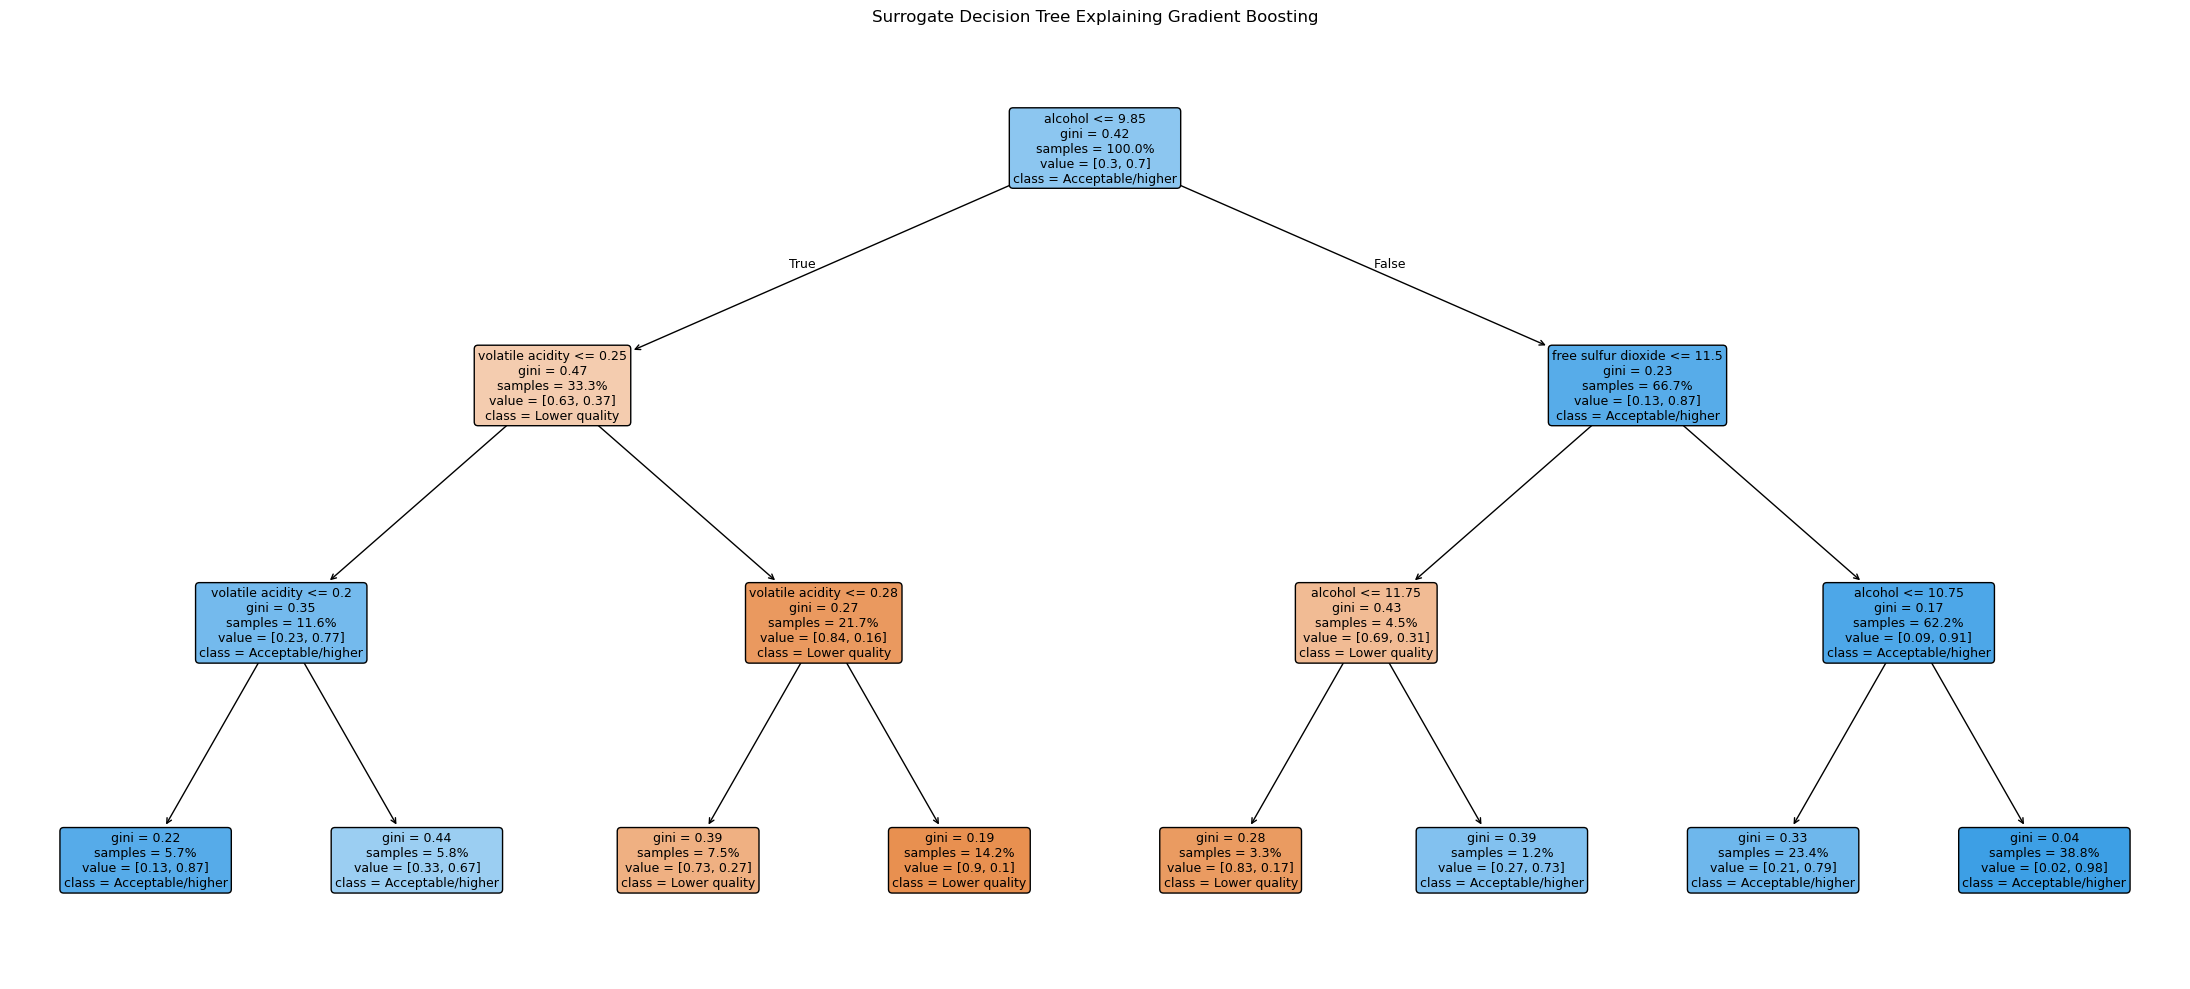

In [72]:
plt.figure(figsize=(22, 10))

plot_tree(
    surrogate_model,
    feature_names=X_train.columns,
    class_names=[
        "Lower quality",
        "Acceptable/higher"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=9
)

plt.title(
    "Surrogate Decision Tree Explaining Gradient Boosting"
)

plt.tight_layout()
plt.show()

### Interpretation of the Surrogate Decision Tree

The first decision in the surrogate tree uses an alcohol threshold of approximately **9.85**. This indicates that alcohol is the most useful starting feature for approximating the Gradient Boosting model.

For wines with alcohol at or below 9.85, the next important decisions primarily involve **volatile acidity**.

For wines with alcohol above 9.85, the next decision involves **free sulfur dioxide**, followed by additional alcohol thresholds.

The main explanatory features appearing in the tree are therefore:

- alcohol,
- volatile acidity,
- and free sulfur dioxide.

This broadly agrees with the earlier feature-importance analysis, where alcohol was the most important predictor.

The branches labelled **True** and **False** show whether an observation satisfies the condition written in a decision node:

- True follows the left branch.
- False follows the right branch.

The orange nodes are dominated by lower-quality predictions, while the blue nodes are dominated by acceptable or higher-quality predictions. Darker colours indicate greater dominance of one predicted class.

The surrogate achieved **87.14% test fidelity**. Therefore, this tree provides a useful simplified explanation of the final Gradient Boosting model, but it does not reproduce every Gradient Boosting decision.

In [73]:
final_model_summary = pd.DataFrame({
    "Model": [
        "Tuned Gradient Boosting (default threshold)",
        "Tuned Gradient Boosting (threshold 0.68)",
        "Tuned Random Forest"
    ],
    "Main Purpose": [
        "Highest overall accuracy",
        "Stronger lower-quality detection",
        "Alternative lower-quality detection"
    ],
    "Test Accuracy (%)": [
        tuned_gb_test_accuracy * 100,
        threshold_test_accuracy * 100,
        74.91
    ],
    "Lower-quality Precision (%)": [
        lower_quality_precision_gb * 100,
        threshold_test_precision_0 * 100,
        63.00
    ],
    "Lower-quality Recall (%)": [
        lower_quality_recall_gb * 100,
        threshold_test_recall_0 * 100,
        65.00
    ],
    "Lower-quality F1-score (%)": [
        lower_quality_f1_gb * 100,
        threshold_test_f1_0 * 100,
        64.00
    ]
}).round(2)

final_model_summary

,Model,Main Purpose,Test Accuracy (%),Lower-quality Precision (%),Lower-quality Recall (%),Lower-quality F1-score (%)
0,Tuned Gradient Boosting (default threshold),Highest overall accuracy,76.67,67.49,60.74,63.94
1,Tuned Gradient Boosting (threshold 0.68),Stronger lower-quality detection,71.88,56.40,76.67,64.99
2,Tuned Random Forest,Alternative lower-quality detection,74.91,63.00,65.00,64.00


## Final Model Selection

The tuned Gradient Boosting classifier with the default decision threshold is selected as the final general-purpose model.

It achieved:

- Test accuracy: **76.67%**
- Cross-validation accuracy: **77.43%**
- Lower-quality precision: **67.49%**
- Lower-quality recall: **60.74%**
- Lower-quality F1-score: **63.94%**
- 95% confidence interval for accuracy: **73.52% to 79.57%**

The complete accuracy confidence interval is above the project's 70% objective. Cross-validation accuracy and test accuracy are also close, indicating relatively stable generalization performance.

### Quality-Control Alternative

Changing the decision threshold from 0.50 to 0.68 reduced overall accuracy to **71.88%**, but increased lower-quality recall from **60.74% to 76.67%**.

The threshold-adjusted model detected approximately 77 out of every 100 lower-quality wines. Its lower-quality F1-score also increased slightly to **64.99%**.

This version would be preferable when failing to detect a lower-quality wine is considered more costly than incorrectly rejecting an acceptable wine.

### Practical Model Choices

- **Default Gradient Boosting:** best overall accuracy.
- **Threshold-adjusted Gradient Boosting:** best lower-quality recall.
- **Tuned Random Forest:** compromise between overall accuracy and lower-quality detection.

The final choice should depend on the operational cost of each type of classification error.

## Project Conclusion

This project developed a binary classification system for predicting whether a white wine belongs to the lower-quality or acceptable/higher-quality category.

Wine quality scores from 3 to 5 were classified as lower quality, while scores from 6 to 9 were classified as acceptable or higher quality.

The majority-class baseline achieved **65.95% accuracy** by predicting every wine as acceptable or higher quality. This demonstrated why accuracy had to be considered together with class-specific precision, recall and F1-score.

K-Nearest Neighbors was sensitive to feature scale. Normalization improved its test accuracy from **67.84% to 73.27%**. Grid Search improved the tuned KNN result to **75.16%**.

Ensemble models produced stronger results. The initial Random Forest achieved **76.29%**, while the tuned Gradient Boosting classifier produced the highest test accuracy of **76.67%**.

The final model's 95% bootstrap confidence interval for accuracy ranged from **73.52% to 79.57%**, remaining above the 70% project objective.

Alcohol was consistently identified as the most influential predictor. Density, volatile acidity and sulfur-dioxide measurements also contributed substantially to model predictions.

A surrogate Decision Tree reproduced **87.14%** of the final model's test predictions. This provided an interpretable approximation of the more complicated Gradient Boosting model.

The project demonstrates that model selection should not depend on accuracy alone. Threshold adjustment increased lower-quality recall to **76.67%**, showing how a classifier can be adapted to different business and quality-control priorities.

## Limitations

- The dataset represents Portuguese white vinho verde wines and may not represent every wine type, region or production process.
- Converting the original quality score into two classes removes differences within each category.
- Approximately 66% of observations belong to the acceptable/higher-quality class, creating moderate class imbalance.
- The model uses physicochemical measurements but does not include production methods, grape varieties, storage conditions, price or detailed sensory information.
- The confidence intervals describe uncertainty within the available test sample and do not guarantee identical performance on external data.
- Feature importance indicates predictive usefulness but does not establish causation.
- The surrogate Decision Tree approximates the final model and disagrees with it on approximately 13% of test observations.
- Multiple models were compared using the same test set. A completely independent external validation dataset would provide a stronger final assessment.

## Future Improvements

Future work could include:

- collecting an independent validation dataset,
- testing the model on wines from other regions and producers,
- adding production, storage and sensory variables,
- investigating multiclass prediction of the original quality scores,
- experimenting with additional boosting algorithms,
- improving probability calibration,
- selecting decision thresholds according to real quality-control costs,
- and monitoring model performance after deployment.